In [1]:

# Brain Stroke CT Classification
# Models : MobileNetV3Small | MobileNetV2 | EfficientNetB0
# Task   : 3-class (Normal / Ischemia / Bleeding)
# Author : Tasnim Mohamed Anzize


# CELL 1 — IMPORTS & REPRODUCIBILITY

import os
import random
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import (
    MobileNetV2,
    MobileNetV3Small,
    EfficientNetB0,
)
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as preprocess_v2
from tensorflow.keras.applications.mobilenet_v3  import preprocess_input as preprocess_v3
from tensorflow.keras.applications.efficientnet  import preprocess_input as preprocess_eff
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU devices        : {tf.config.list_physical_devices('GPU')}")


2026-05-29 04:24:33.452813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780028673.475949    2477 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780028673.483410    2477 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780028673.503911    2477 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780028673.503930    2477 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780028673.503932    2477 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 2 — CONFIGURATION

BASE_DIR  = "/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"
FLAT_DIR  = "/kaggle/working/dataset_flat"
SAVE_DIR  = "/kaggle/working"

IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
NUM_CLASSES = 3

# Transfer learning phases
EPOCHS_FROZEN   = 15   # Phase 1: train head only
EPOCHS_FINETUNE = 50   # Phase 2: fine-tune top layers
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-5
UNFREEZE_TOP    = 80   # number of top base-model layers to unfreeze

print("Configuration loaded.")
print(f"  BASE_DIR  : {BASE_DIR}")
print(f"  FLAT_DIR  : {FLAT_DIR}")
print(f"  SAVE_DIR  : {SAVE_DIR}")
print(f"  IMG_SIZE  : {IMG_SIZE}")
print(f"  BATCH     : {BATCH_SIZE}")


Configuration loaded.
  BASE_DIR  : /kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset
  FLAT_DIR  : /kaggle/working/dataset_flat
  SAVE_DIR  : /kaggle/working
  IMG_SIZE  : (224, 224)
  BATCH     : 32


In [3]:
# CELL 2b — BUILD FLAT DIRECTORY STRUCTURE (symlinks, no data copy)

CLASS_MAP = {
    "Bleeding" : f"{BASE_DIR}/Bleeding/PNG",
    "Ischemia" : f"{BASE_DIR}/Ischemia/PNG",
    "Normal"   : f"{BASE_DIR}/Normal/PNG",
}

for class_name, src_path in CLASS_MAP.items():
    dst_path = os.path.join(FLAT_DIR, class_name)
    os.makedirs(dst_path, exist_ok=True)
    for fname in os.listdir(src_path):
        if fname.lower().endswith(".png"):
            src_file = os.path.join(src_path, fname)
            dst_file = os.path.join(dst_path, fname)
            if not os.path.exists(dst_file):
                os.symlink(src_file, dst_file)

print("Flat dataset structure:")
for cls in sorted(os.listdir(FLAT_DIR)):
    n = len(os.listdir(os.path.join(FLAT_DIR, cls)))
    print(f"  {cls:<12} -> {n} images")

print(f"\nFLAT_DIR ready: {FLAT_DIR}")


Flat dataset structure:
  Bleeding     -> 1093 images
  Ischemia     -> 1130 images
  Normal       -> 4427 images

FLAT_DIR ready: /kaggle/working/dataset_flat


In [4]:
# CELL 2c — STRATIFIED 70 / 15 / 15 SPLIT
#
# FIX: replaces ImageDataGenerator(validation_split=0.30) which:
#   - did NOT stratify class distribution
#   - made val_gen and test_gen read the SAME 30% slice
#
# Now: sklearn train_test_split with stratify=labels guarantees
# class balance in every subset and a clean held-out test set.

CLASS_NAMES_SORTED = sorted(os.listdir(FLAT_DIR))  # alphabetical
CLASS_TO_IDX       = {cls: i for i, cls in enumerate(CLASS_NAMES_SORTED)}
NUM_CLASSES        = len(CLASS_NAMES_SORTED)

# Collect all file paths + integer labels
all_paths, all_labels = [], []
for cls in CLASS_NAMES_SORTED:
    cls_dir = os.path.join(FLAT_DIR, cls)
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith(".png"):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(CLASS_TO_IDX[cls])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total images : {len(all_paths)}")
for cls, idx in CLASS_TO_IDX.items():
    n = (all_labels == idx).sum()
    print(f"  {cls:<12} ({idx}) -> {n} images  ({n/len(all_labels)*100:.1f}%)")

# Step 1: 70% train / 30% temp
train_paths, valtest_paths, train_labels, valtest_labels = train_test_split(
    all_paths, all_labels,
    test_size    = 0.30,
    stratify     = all_labels,
    random_state = SEED,
)

# Step 2: split 30% into 15% val + 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    valtest_paths, valtest_labels,
    test_size    = 0.50,   # 50% of 30% = 15% of total
    stratify     = valtest_labels,
    random_state = SEED,
)

print(f"\nSplit sizes:")
print(f"  Train : {len(train_paths):>5}  ({len(train_paths)/len(all_paths)*100:.1f}%)")
print(f"  Val   : {len(val_paths):>5}  ({len(val_paths)/len(all_paths)*100:.1f}%)")
print(f"  Test  : {len(test_paths):>5}  ({len(test_paths)/len(all_paths)*100:.1f}%)")

print("\nClass distribution per split:")
for split_name, paths, labels in [
    ("Train", train_paths, train_labels),
    ("Val",   val_paths,   val_labels),
    ("Test",  test_paths,  test_labels),
]:
    dist = "  ".join(
        f"{cls}={( labels==i).sum()}({(labels==i).sum()/len(labels)*100:.0f}%)"
        for cls, i in CLASS_TO_IDX.items()
    )
    print(f"  {split_name:<6}: {dist}")

# Save splits for full reproducibility
for split_name, paths, labels in [
    ("train", train_paths, train_labels),
    ("val",   val_paths,   val_labels),
    ("test",  test_paths,  test_labels),
]:
    df = pd.DataFrame({
        "filepath" : paths,
        "label"    : labels,
        "class"    : [CLASS_NAMES_SORTED[l] for l in labels],
    })
    csv_path = os.path.join(SAVE_DIR, f"split_{split_name}.csv")
    df.to_csv(csv_path, index=False)
    print(f"  Saved: split_{split_name}.csv  ({len(df)} rows)")

print("\nSplit complete. train_paths / val_paths / test_paths are ready.")


Total images : 6650
  Bleeding     (0) -> 1093 images  (16.4%)
  Ischemia     (1) -> 1130 images  (17.0%)
  Normal       (2) -> 4427 images  (66.6%)

Split sizes:
  Train :  4655  (70.0%)
  Val   :   997  (15.0%)
  Test  :   998  (15.0%)

Class distribution per split:
  Train : Bleeding=765(16%)  Ischemia=791(17%)  Normal=3099(67%)
  Val   : Bleeding=164(16%)  Ischemia=169(17%)  Normal=664(67%)
  Test  : Bleeding=164(16%)  Ischemia=170(17%)  Normal=664(67%)
  Saved: split_train.csv  (4655 rows)
  Saved: split_val.csv  (997 rows)
  Saved: split_test.csv  (998 rows)

Split complete. train_paths / val_paths / test_paths are ready.


In [5]:
# CELL 2d — CLASS WEIGHTS
#
# weights now computed from train_labels only .
# Using the full directory would leak val/test class distribution
# into the training loss function.

weights = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(train_labels),
    y            = train_labels,
)
CLASS_WEIGHTS = dict(enumerate(weights))

print("Class weights (balanced, from train split only):")
for idx, cls in enumerate(CLASS_NAMES_SORTED):
    print(f"  {idx} — {cls:<12} -> weight = {CLASS_WEIGHTS[idx]:.4f}")

print("\nHigher weight = model penalised more for misclassifying that class.")


Class weights (balanced, from train split only):
  0 — Bleeding     -> weight = 2.0283
  1 — Ischemia     -> weight = 1.9617
  2 — Normal       -> weight = 0.5007

Higher weight = model penalised more for misclassifying that class.


In [6]:
# CELL 2e — BALANCED GENERATOR
# ONLY sees training images — never val or test files.

class BalancedGenerator(keras.utils.Sequence):
    """
    Oversamples minority classes to match majority count each epoch.
    Applies mild augmentation (no vertical flip — clinically conservative).
    Returns (images, one-hot labels) for softmax multiclass output.
    """

    def __init__(self, file_paths, labels, class_names, preprocess_fn,
                 img_size=(224, 224), batch_size=32, augment=True, seed=42):

        self.class_names   = class_names
        self.preprocess_fn = preprocess_fn
        self.img_size      = img_size
        self.batch_size    = batch_size
        self.augment       = augment
        self.seed          = seed

        # Group file paths by class index using pre-computed labels
        self.class_files = {i: [] for i in range(len(class_names))}
        for path, label in zip(file_paths, labels):
            self.class_files[label].append(path)

        # Oversample minority classes to majority count
        max_count    = max(len(f) for f in self.class_files.values())
        self.samples = []

        random.seed(seed)
        for idx, files in self.class_files.items():
            oversampled = files.copy()
            while len(oversampled) < max_count:
                oversampled.append(random.choice(files))
            self.samples.extend([(fp, idx) for fp in oversampled])

        random.shuffle(self.samples)

        print(f"  BalancedGenerator ready (train only):")
        for idx, cls in enumerate(class_names):
            print(f"    {cls:<12}: {len(self.class_files[idx])} original  "
                  f"-> {max_count} after oversample")
        print(f"    Total samples    : {len(self.samples)}")
        print(f"    Batches per epoch: {len(self)}")

    def __len__(self):
        return len(self.samples) // self.batch_size

    def on_epoch_end(self):
        random.seed(self.seed)
        random.shuffle(self.samples)

    def _augment(self, img):
        """Mild, clinically conservative augmentation. No vertical flip."""
        if random.random() < 0.5:
            img = np.fliplr(img)
        if random.random() < 0.5:
            angle = random.uniform(-10, 10)
            M     = cv2.getRotationMatrix2D(
                        (img.shape[1]//2, img.shape[0]//2), angle, 1.0)
            img   = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                                   borderMode=cv2.BORDER_REFLECT)
        if random.random() < 0.5:
            zoom   = random.uniform(0.9, 1.1)
            h, w   = img.shape[:2]
            nh, nw = int(h * zoom), int(w * zoom)
            img    = cv2.resize(img, (nw, nh))
            y0     = max((nh - h) // 2, 0)
            x0     = max((nw - w) // 2, 0)
            img    = img[y0:y0+h, x0:x0+w]
            img    = cv2.resize(img, (w, h))
        if random.random() < 0.5:
            dx = int(random.uniform(-0.1, 0.1) * img.shape[1])
            dy = int(random.uniform(-0.1, 0.1) * img.shape[0])
            M  = np.float32([[1, 0, dx], [0, 1, dy]])
            img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                                 borderMode=cv2.BORDER_REFLECT)
        return img

    def __getitem__(self, idx):
        batch  = self.samples[idx * self.batch_size : (idx + 1) * self.batch_size]
        images, label_out = [], []
        for filepath, class_idx in batch:
            img = cv2.imread(filepath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            if self.augment:
                img = self._augment(img)
            img = self.preprocess_fn(img.astype(np.float32))
            one_hot = np.zeros(len(self.class_names), dtype=np.float32)
            one_hot[class_idx] = 1.0
            images.append(img)
            label_out.append(one_hot)
        return np.array(images), np.array(label_out)


# ── NumpyGenerator for val / test (no augmentation, explicit file list)
class NumpyGenerator(keras.utils.Sequence):
    """
    Serves a fixed list of file paths + labels.
    No augmentation. No oversampling.
    Used for val and test sets only.
    """

    def __init__(self, file_paths, labels, class_names,
                 preprocess_fn, img_size, batch_size, shuffle=False):
        self.file_paths    = np.array(file_paths)
        self.labels        = np.array(labels)
        self.class_names   = class_names
        self.preprocess_fn = preprocess_fn
        self.img_size      = img_size
        self.batch_size    = batch_size
        self.shuffle       = shuffle
        self.indices       = np.arange(len(file_paths))

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def reset(self):
        self.indices = np.arange(len(self.file_paths))

    def __getitem__(self, idx):
        batch_idx = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]
        images, label_out = [], []
        for i in batch_idx:
            img = cv2.imread(self.file_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            img = self.preprocess_fn(img.astype(np.float32))
            one_hot = np.zeros(len(self.class_names), dtype=np.float32)
            one_hot[self.labels[i]] = 1.0
            images.append(img)
            label_out.append(one_hot)
        return np.array(images), np.array(label_out)

    @property
    def filepaths(self):
        return self.file_paths[self.indices]


print("BalancedGenerator and NumpyGenerator defined.")


BalancedGenerator and NumpyGenerator defined.


In [7]:
# CELL 2f — FOCAL LOSS
#
# Focal Loss = -alpha * (1-p)^gamma * log(p)
# gamma > 0 down-weights easy majority predictions,
# focusing learning on hard minority examples (subtle ischemia, small bleeds).

import tensorflow as tf

@tf.keras.utils.register_keras_serializable(package="Custom")
class FocalLoss(keras.losses.Loss):
    """
    Categorical Focal Loss for softmax multiclass output.

    Args:
        gamma : focusing parameter (default 2.0)
        alpha : balance parameter  (default 0.25)
    """

    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) \
                  - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        p_t     = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        focal_w = tf.pow(1.0 - p_t, self.gamma)
        alpha_t = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
        loss    = alpha_t * focal_w * bce
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "alpha": self.alpha})
        return cfg


focal_loss = FocalLoss(gamma=2.0, alpha=0.25)

print("Focal Loss ready.")
print(f"  gamma = 2.0  (focusing — down-weights easy examples)")
print(f"  alpha = 0.25 (balance  — reduces majority-class weight)")


Focal Loss ready.
  gamma = 2.0  (focusing — down-weights easy examples)
  alpha = 0.25 (balance  — reduces majority-class weight)


Class distribution — full dataset
  Bleeding     ->  1093 images
  Ischemia     ->  1130 images
  Normal       ->  4427 images

  TOTAL: 6650 images  |  3 classes

  Imbalance ratios:
    Bleeding     -> 1093 images  (ratio 4.05x vs majority)
    Ischemia     -> 1130 images  (ratio 3.92x vs majority)
    Normal       -> 4427 images  (ratio 1.00x vs majority)


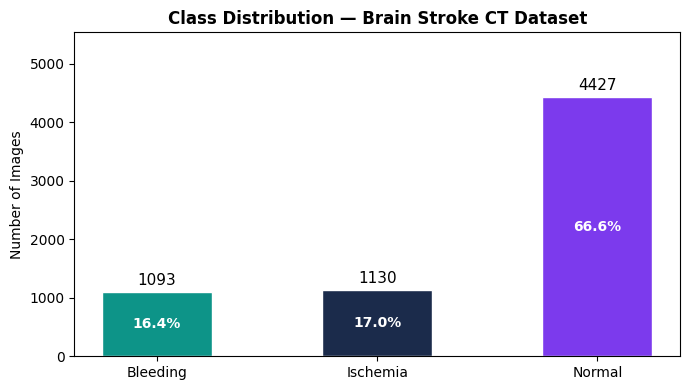

Saved: class_distribution.png


In [8]:
# CELL 3 — DATASET EXPLORATION

print("=" * 50)
print("Class distribution — full dataset")
print("=" * 50)

class_counts = {}
for cls in CLASS_NAMES_SORTED:
    n = (all_labels == CLASS_TO_IDX[cls]).sum()
    class_counts[cls] = n
    print(f"  {cls:<12} -> {n:>5} images")

total_images = len(all_paths)
print(f"\n  TOTAL: {total_images} images  |  {NUM_CLASSES} classes")

max_count = max(class_counts.values())
print("\n  Imbalance ratios:")
for cls, n in class_counts.items():
    print(f"    {cls:<12} -> {n} images  (ratio {max_count/n:.2f}x vs majority)")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    class_counts.keys(),
    class_counts.values(),
    color     = ["#0D9488", "#1B2B4B", "#7C3AED"],
    edgecolor = "white",
    width     = 0.5,
)
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_title("Class Distribution — Brain Stroke CT Dataset",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max_count * 1.25)
for bar, (cls, n) in zip(bars, class_counts.items()):
    pct = n / total_images * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f"{pct:.1f}%", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")


In [9]:
# CELL 4 — DATA GENERATORS
#
# FIX: build_generators() now takes explicit pre-split file lists.
# train_gen -> BalancedGenerator on train_paths  (70%, oversampled, augmented)
# val_gen   -> NumpyGenerator    on val_paths    (15%, no augmentation)
# test_gen  -> NumpyGenerator    on test_paths   (15%, no augmentation, NEVER
#              seen during training or early stopping)

def build_generators(preprocess_fn,
                     img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """
    Returns (train_gen, val_gen, test_gen).
    Requires Cell 2c to have run (train_paths, val_paths, test_paths).
    """
    train_gen = BalancedGenerator(
        file_paths    = train_paths,
        labels        = train_labels,
        class_names   = CLASS_NAMES_SORTED,
        preprocess_fn = preprocess_fn,
        img_size      = img_size,
        batch_size    = batch_size,
        augment       = True,
        seed          = SEED,
    )
    val_gen = NumpyGenerator(
        val_paths, val_labels, CLASS_NAMES_SORTED,
        preprocess_fn, img_size, batch_size, shuffle=False,
    )
    test_gen = NumpyGenerator(
        test_paths, test_labels, CLASS_NAMES_SORTED,
        preprocess_fn, img_size, 1, shuffle=False,
    )
    print(f"  Train batches/epoch : {len(train_gen)}")
    print(f"  Val images          : {len(val_paths)}")
    print(f"  Test images         : {len(test_paths)}  (held-out, clean)")
    return train_gen, val_gen, test_gen


In [10]:
# CELL 5 — MODEL BUILDER 
UNFREEZE_TOP = 80   

LAST_CONV_LAYER = {
    "MobileNetV3Small" : "att_map",   
    "MobileNetV2"      : "att_map",
    "EfficientNetB0"   : "att_map",
}

def build_model(base_name, num_classes=NUM_CLASSES):
    """
    Two-phase transfer learning + spatial attention block.
    Phase 1: frozen base, train classification head  (LR=1e-3)
    Phase 2: unfreeze top 80 layers                  (LR=1e-5)

    NEW: spatial attention block inserted between the last conv layer
    and GAP — forces the model to localise the lesion rather than
    learning global texture features.

    Architecture:
        Backbone → att_conv1 → att_bn → att_map (sigmoid)
                → attended_features (Multiply)
                → GAP → BN → Dense(256) → Dense(128) → Softmax

    Output : softmax (multiclass, 3 classes)
    Loss   : Focal Loss (gamma=2, alpha=0.25)
    """
    input_tensor = keras.Input(shape=IMG_SHAPE, name="input_image")
    base_kwargs  = dict(input_tensor=input_tensor, include_top=False,
                        weights="imagenet")

    if base_name == "MobileNetV3Small":
        base = MobileNetV3Small(**base_kwargs, minimalistic=False)
    elif base_name == "MobileNetV2":
        base = MobileNetV2(**base_kwargs)
    elif base_name == "EfficientNetB0":
        base = EfficientNetB0(**base_kwargs)
    else:
        raise ValueError(f"Unknown model: {base_name}")

    base.trainable = False

    # Spatial Attention Block 
    # feat_maps shape: (batch, H, W, C)
    # e.g. EfficientNetB0 → (batch, 7, 7, 1280)
    #      MobileNetV2    → (batch, 7, 7, 1280)
    #      MobileNetV3    → (batch, 7, 7, 576)
    feat_maps = base.output

    # 1x1 convolutions to learn which spatial regions matter
    att = layers.Conv2D(256, (1, 1), activation="relu",
                         padding="same", name="att_conv1")(feat_maps)
    att = layers.BatchNormalization(name="att_bn")(att)
    att = layers.Conv2D(1,   (1, 1), activation="sigmoid",
                         padding="same", name="att_map")(att)
    # att shape: (batch, H, W, 1) — learned attention heatmap
    # sigmoid ensures values in [0,1]: 1 = lesion region, 0 = background

    # Element-wise multiplication: suppress background, amplify lesion
    attended = layers.Multiply(name="attended_features")([feat_maps, att])

    # Classification Head 
    x = layers.GlobalAveragePooling2D(name="gap")(attended)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dense(256, activation="relu",
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      name="dense_256")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)
    x = layers.Dense(128, activation="relu",
                      kernel_regularizer=keras.regularizers.l2(1e-4),
                      name="dense_128")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)
    output = layers.Dense(num_classes, activation="softmax",
                           name="predictions")(x)

    model = keras.Model(inputs=input_tensor, outputs=output, name=base_name)
    return model, base


def compile_model(model, learning_rate):
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss      = focal_loss,
        metrics   = [
            "accuracy",
            tf.keras.metrics.AUC(name="auc", multi_label=False),
        ],
    )


def get_callbacks(model_name, phase):
    checkpoint_path = f"{SAVE_DIR}/{model_name}_phase{phase}_best.keras"
    return [
        ModelCheckpoint(
            filepath       = checkpoint_path,
            monitor        = "val_auc",
            save_best_only = True,
            mode           = "max",
            verbose        = 0,
        ),
        EarlyStopping(
            monitor              = "val_auc",
            patience             = 5,
            restore_best_weights = True,
            mode                 = "max",
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,
            patience = 3,
            min_lr   = 1e-7,
            verbose  = 1,
        ),
    ]


def get_last_conv_layer_name(base_model, model_name=None):
    """
    All 3 models now share 'att_map' as the Grad-CAM target layer.
    The attention map IS the localisation signal — no need to go
    deeper into the backbone.
    """
    if model_name and model_name in LAST_CONV_LAYER:
        name = LAST_CONV_LAYER[model_name]
        print(f"  Last conv layer (lookup)  : {name}")
        return name
    for layer in reversed(base_model.layers):
        try:
            if len(layer.output.shape) == 4:
                print(f"  Last conv layer (dynamic) : {layer.name}")
                return layer.name
        except Exception:
            continue
    raise ValueError("No spatial layer found in base model")


print("Model builder ready — WITH spatial attention block.")
print("  Attention layer  : att_map  (1x1 Conv sigmoid)")
print("  Attended output  : attended_features  (backbone x att_map)")
print("  UNFREEZE_TOP     : 80 layers unfrozen in Phase 2")
print("  Output           : softmax  (3 classes)")
print("  Loss             : Focal Loss  (gamma=2, alpha=0.25)")
print("  Monitor          : val_auc")

Model builder ready — WITH spatial attention block.
  Attention layer  : att_map  (1x1 Conv sigmoid)
  Attended output  : attended_features  (backbone x att_map)
  UNFREEZE_TOP     : 80 layers unfrozen in Phase 2
  Output           : softmax  (3 classes)
  Loss             : Focal Loss  (gamma=2, alpha=0.25)
  Monitor          : val_auc


In [11]:
# CELL 6 — TRAINING LOOP  (all 3 models)

EPOCHS_FROZEN   = 15    # Phase 1 — unchanged
EPOCHS_FINETUNE = 50    # Phase 2 — increased 30 → 50

MODEL_CONFIGS = {
    "MobileNetV3Small" : preprocess_v3,
    "MobileNetV2"      : preprocess_v2,
    "EfficientNetB0"   : preprocess_eff,
}

trained_models     = {}
training_histories = {}
last_conv_layers   = {}

for model_name, preprocess_fn in MODEL_CONFIGS.items():
    print("\n" + "=" * 60)
    print(f"  Training: {model_name}")
    print("=" * 60)

    print("\n[1/4] Building data generators...")
    train_gen, val_gen, test_gen = build_generators(preprocess_fn)

    print("\n[2/4] Building model...")
    model, base = build_model(model_name)
    print(f"  Total parameters : {model.count_params():,}")
    last_conv_layers[model_name] = get_last_conv_layer_name(base, model_name)

    # ── Phase 1: frozen backbone, train head + attention only ─────────────
    print(f"\n[3/4] Phase 1 — frozen base ({EPOCHS_FROZEN} epochs max)...")
    compile_model(model, LR_HEAD)
    h1 = model.fit(
        train_gen,
        epochs          = EPOCHS_FROZEN,
        validation_data = val_gen,
        callbacks       = [
            ModelCheckpoint(
                filepath       = f"{SAVE_DIR}/{model_name}_phase1_best.keras",
                monitor        = "val_auc",
                save_best_only = True,
                mode           = "max",
                verbose        = 0,
            ),
            EarlyStopping(
                monitor              = "val_auc",
                patience             = 5,        # phase 1 — keep short
                restore_best_weights = True,
                mode                 = "max",
                verbose              = 1,
            ),
            ReduceLROnPlateau(
                monitor  = "val_loss",
                factor   = 0.5,
                patience = 3,
                min_lr   = 1e-7,
                verbose  = 1,
            ),
        ],
        class_weight    = CLASS_WEIGHTS,
        verbose         = 1,
    )

    # ── Phase 2: unfreeze top 80 layers, deep fine-tuning ─────────────────
    print(f"\n[4/4] Phase 2 — fine-tune top {UNFREEZE_TOP} layers "
          f"({EPOCHS_FINETUNE} epochs max)...")
    base.trainable = True
    for layer in base.layers[:-UNFREEZE_TOP]:
        layer.trainable = False
    for layer in base.layers[-UNFREEZE_TOP:]:
        layer.trainable = True

    trainable_count = sum(1 for l in base.layers if l.trainable)
    print(f"  Trainable backbone layers : {trainable_count} / {len(base.layers)}")

    compile_model(model, LR_FINETUNE)
    h2 = model.fit(
        train_gen,
        epochs          = EPOCHS_FINETUNE,
        validation_data = val_gen,
        callbacks       = [
            ModelCheckpoint(
                filepath       = f"{SAVE_DIR}/{model_name}_phase2_best.keras",
                monitor        = "val_auc",
                save_best_only = True,
                mode           = "max",
                verbose        = 0,
            ),
            EarlyStopping(
                monitor              = "val_auc",
                patience             = 10,       # phase 2 — more patience
                restore_best_weights = True,     # for attention to converge
                mode                 = "max",
                verbose              = 1,
            ),
            ReduceLROnPlateau(
                monitor  = "val_loss",
                factor   = 0.5,
                patience = 4,                    # slightly more patience too
                min_lr   = 1e-7,
                verbose  = 1,
            ),
        ],
        class_weight    = CLASS_WEIGHTS,
        verbose         = 1,
    )

    trained_models[model_name]     = model
    training_histories[model_name] = (h1, h2)
    print(f"\n✓ {model_name} training complete.")
    print(f"  Phase 1 epochs run : {len(h1.history['val_auc'])}")
    print(f"  Phase 2 epochs run : {len(h2.history['val_auc'])}")
    print(f"  Best val_auc       : {max(h2.history['val_auc']):.4f}")

print("\n" + "=" * 60)
print("All 3 models trained.")
print("=" * 60)


  Training: MobileNetV3Small

[1/4] Building data generators...
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)

[2/4] Building model...


I0000 00:00:1780028686.837402    2477 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  Total parameters : 1,271,412
  Last conv layer (lookup)  : att_map

[3/4] Phase 1 — frozen base (15 epochs max)...
Epoch 1/15


I0000 00:00:1780028695.859932    2538 cuda_dnn.cc:529] Loaded cuDNN version 91002


290/290 ━━━━━━━━━━━━━━━━━━━━ 83s 254ms/step - accuracy: 0.4893 - auc: 0.6713 - loss: 0.2024 - val_accuracy: 0.7563 - val_auc: 0.9004 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 71s 243ms/step - accuracy: 0.6823 - auc: 0.8517 - loss: 0.1185 - val_accuracy: 0.7583 - val_auc: 0.9109 - val_loss: 0.0849 - learning_rate: 0.0010
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 73s 253ms/step - accuracy: 0.7341 - auc: 0.8961 - loss: 0.1058 - val_accuracy: 0.8355 - val_auc: 0.9505 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 75s 257ms/step - accuracy: 0.7822 - auc: 0.9221 - loss: 0.0948 - val_accuracy: 0.8385 - val_auc: 0.9580 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 73s 251ms/step - accuracy: 0.8018 - auc: 0.9371 - loss: 0.0865 - val_accuracy: 0.8475 - val_auc: 0.9595 - val_loss: 0.0641 - learning_rate: 0.0010
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 77s 264ms/step - accuracy: 0.8274 - 

E0000 00:00:1780041444.544339    2477 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


290/290 ━━━━━━━━━━━━━━━━━━━━ 106s 323ms/step - accuracy: 0.5111 - auc: 0.6861 - loss: 0.2427 - val_accuracy: 0.7292 - val_auc: 0.8706 - val_loss: 0.1102 - learning_rate: 0.0010
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 87s 301ms/step - accuracy: 0.6661 - auc: 0.8310 - loss: 0.1321 - val_accuracy: 0.6690 - val_auc: 0.8539 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 80s 277ms/step - accuracy: 0.7112 - auc: 0.8724 - loss: 0.1209 - val_accuracy: 0.7984 - val_auc: 0.9369 - val_loss: 0.0863 - learning_rate: 0.0010
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 84s 289ms/step - accuracy: 0.7495 - auc: 0.8996 - loss: 0.1101 - val_accuracy: 0.7884 - val_auc: 0.9338 - val_loss: 0.0842 - learning_rate: 0.0010
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 82s 282ms/step - accuracy: 0.7785 - auc: 0.9206 - loss: 0.1007 - val_accuracy: 0.8084 - val_auc: 0.9380 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 81s 279ms/step - accuracy: 0.7937 -

E0000 00:00:1780042739.659787    2477 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


290/290 ━━━━━━━━━━━━━━━━━━━━ 111s 312ms/step - accuracy: 0.6586 - auc: 0.8258 - loss: 0.1027 - val_accuracy: 0.8014 - val_auc: 0.9256 - val_loss: 0.0605 - learning_rate: 1.0000e-05
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 91s 314ms/step - accuracy: 0.7337 - auc: 0.8907 - loss: 0.0863 - val_accuracy: 0.7984 - val_auc: 0.9328 - val_loss: 0.0589 - learning_rate: 1.0000e-05
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 89s 307ms/step - accuracy: 0.7799 - auc: 0.9220 - loss: 0.0786 - val_accuracy: 0.8315 - val_auc: 0.9529 - val_loss: 0.0539 - learning_rate: 1.0000e-05
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 90s 312ms/step - accuracy: 0.8112 - auc: 0.9388 - loss: 0.0724 - val_accuracy: 0.8516 - val_auc: 0.9629 - val_loss: 0.0506 - learning_rate: 1.0000e-05
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 88s 303ms/step - accuracy: 0.8358 - auc: 0.9489 - loss: 0.0689 - val_accuracy: 0.8766 - val_auc: 0.9713 - val_loss: 0.0479 - learning_rate: 1.0000e-05
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 87s 299ms/step 

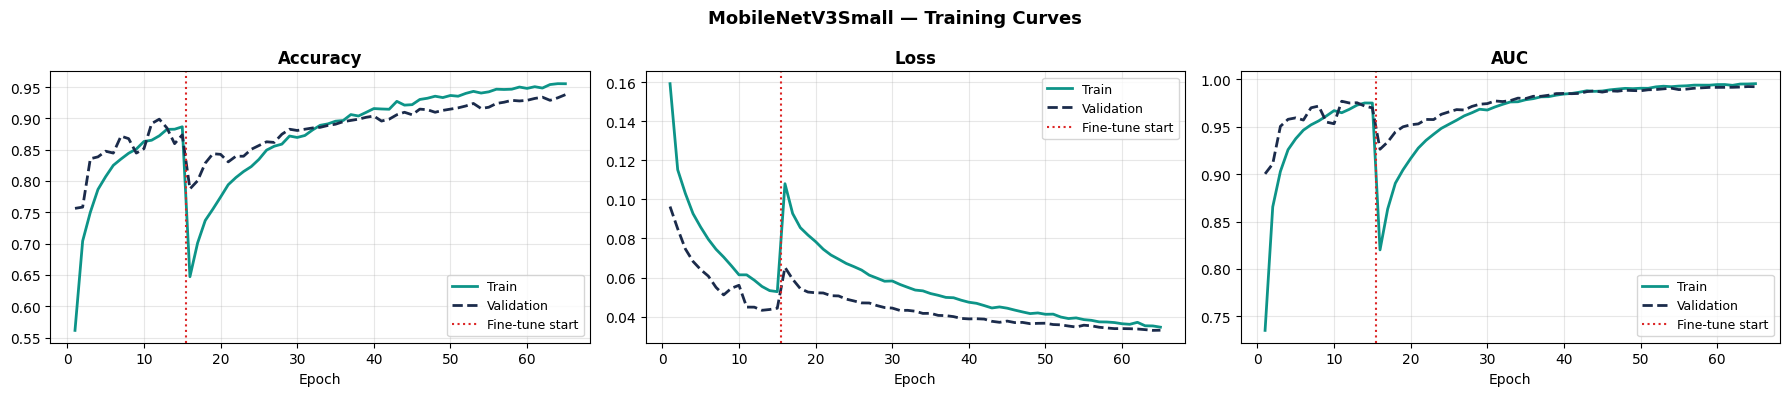

Saved: MobileNetV3Small_curves.png


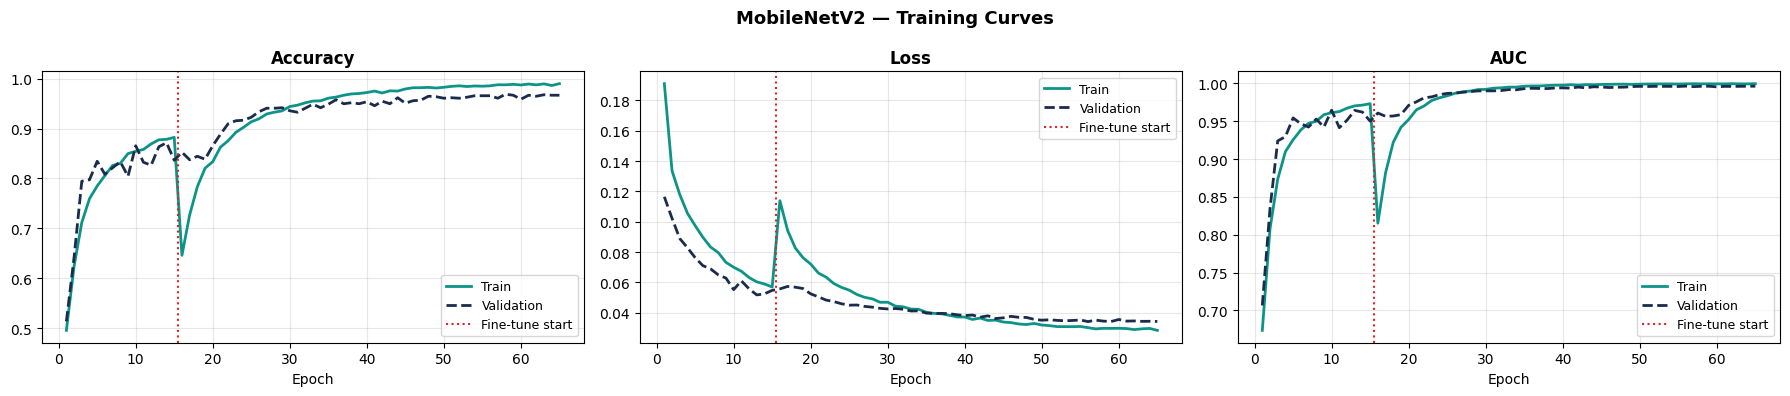

Saved: MobileNetV2_curves.png


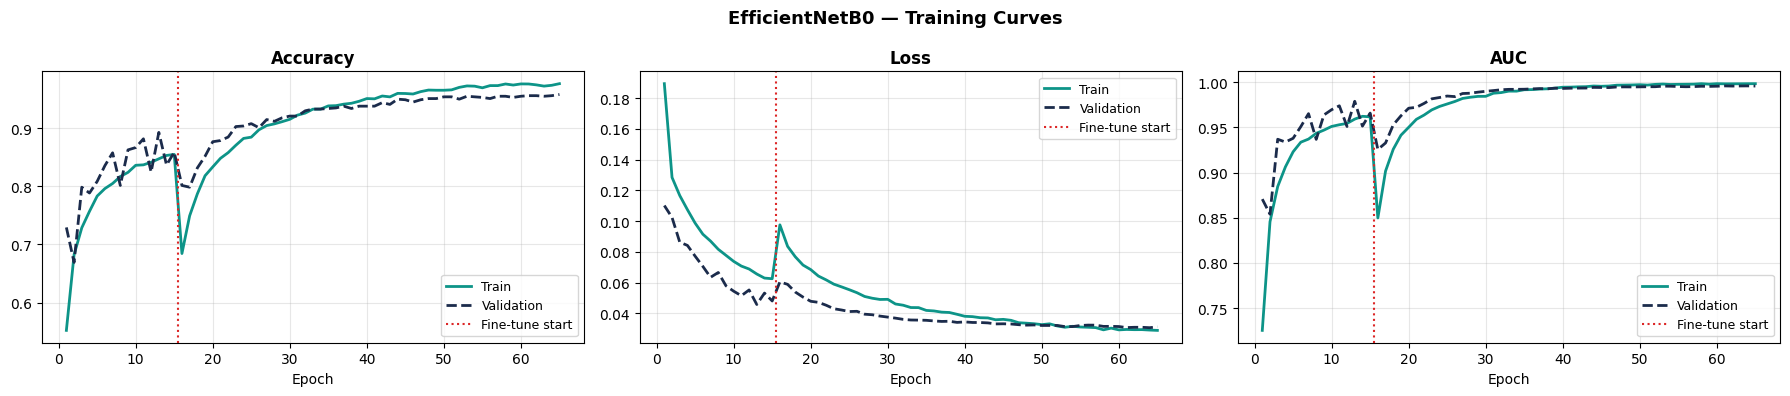

Saved: EfficientNetB0_curves.png


In [22]:
# CELL 7 — TRAINING CURVES

def plot_training_curves(model_name, h1, h2, save_dir=SAVE_DIR):
    acc      = h1.history["accuracy"]     + h2.history["accuracy"]
    val_acc  = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss     = h1.history["loss"]         + h2.history["loss"]
    val_loss = h1.history["val_loss"]     + h2.history["val_loss"]
    auc      = h1.history["auc"]          + h2.history["auc"]
    val_auc  = h1.history["val_auc"]      + h2.history["val_auc"]

    phase_boundary = len(h1.history["accuracy"])
    epochs         = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{model_name} — Training Curves", fontweight="bold", fontsize=13)

    for ax, (train_m, val_m, title) in zip(axes, [
        (acc,  val_acc,  "Accuracy"),
        (loss, val_loss, "Loss"),
        (auc,  val_auc,  "AUC"),
    ]):
        ax.plot(epochs, train_m, label="Train",      color="#0D9488", linewidth=2)
        ax.plot(epochs, val_m,   label="Validation", color="#1B2B4B",
                linewidth=2, linestyle="--")
        ax.axvline(x=phase_boundary + 0.5, color="#DC2626",
                   linestyle=":", linewidth=1.5, label="Fine-tune start")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_curves.png", dpi=150)
    plt.show()
    print(f"Saved: {model_name}_curves.png")

for name, (h1, h2) in training_histories.items():
    plot_training_curves(name, h1, h2)


In [13]:
# CELL 8 — EVALUATION FUNCTIONS
#evaluate_model now returns per-class AUC in addition to macro AUC.

def evaluate_model(model, test_gen, class_names):
    """
    Evaluates a softmax multiclass model on a NumpyGenerator test set.
    argmax on softmax output selects the predicted class.
    Returns metrics dict, y_true, y_pred, y_pred_probs.
    """
    test_gen.reset()

    y_true       = []
    y_pred_probs = []

    for i in range(len(test_gen)):
        x_batch, y_batch = test_gen[i]
        preds = model.predict(x_batch, verbose=0)
        y_true.append(np.argmax(y_batch, axis=1))   # one-hot -> integer
        y_pred_probs.append(preds)                   # softmax probabilities

    y_true       = np.concatenate(y_true)
    y_pred_probs = np.concatenate(y_pred_probs)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    # Macro metrics
    accuracy   = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average="macro",   zero_division=0)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average="macro",  zero_division=0)

    # AUC — macro and per-class
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        auc_macro = roc_auc_score(y_true_bin, y_pred_probs,
                                  multi_class="ovr", average="macro")
        auc_per_class = {
            cls: round(roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i]), 4)
            for i, cls in enumerate(class_names)
        }
    except ValueError:
        auc_macro     = float("nan")
        auc_per_class = {cls: float("nan") for cls in class_names}

    # Specificity per class
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for i in range(len(class_names)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec)
    specificity = np.mean(specificities)

    metrics = {
        "Accuracy"    : round(accuracy    * 100, 2),
        "Sensitivity" : round(rec_macro   * 100, 2),
        "Specificity" : round(specificity * 100, 2),
        "Precision"   : round(prec_macro  * 100, 2),
        "F1-Score"    : round(f1_macro    * 100, 2),
        "AUC"         : round(auc_macro,   4),
        "AUC_per_class": auc_per_class,
    }

    return metrics, y_true, y_pred, y_pred_probs


def plot_confusion_matrix(y_true, y_pred, class_names,
                           model_name, save_dir=SAVE_DIR):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{model_name} — Confusion Matrices", fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Counts", "Normalized"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion.png", dpi=150)
    plt.show()


print("Evaluation functions ready.")
print("  evaluate_model returns macro AUC + per-class AUC dict.")


Evaluation functions ready.
  evaluate_model returns macro AUC + per-class AUC dict.



  Evaluating: MobileNetV3Small
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)


2026-05-29 09:37:20.164607: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-05-29 09:37:25.228530: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


  Accuracy    : 92.69%
  Sensitivity : 90.82%
  Specificity : 95.82%
  Precision   : 88.99%
  F1-Score    : 89.87%
  AUC (macro) : 0.9832
  AUC per class:
    Bleeding    : 0.985
    Ischemia    : 0.981
    Normal      : 0.9836

  Classification Report:
              precision    recall  f1-score   support

    Bleeding       0.85      0.90      0.87       164
    Ischemia       0.85      0.88      0.87       170
      Normal       0.97      0.95      0.96       664

    accuracy                           0.93       998
   macro avg       0.89      0.91      0.90       998
weighted avg       0.93      0.93      0.93       998



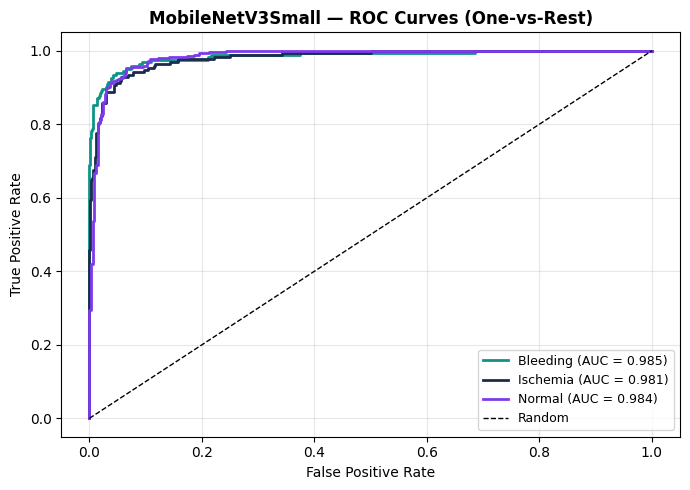

Saved: MobileNetV3Small_roc.png


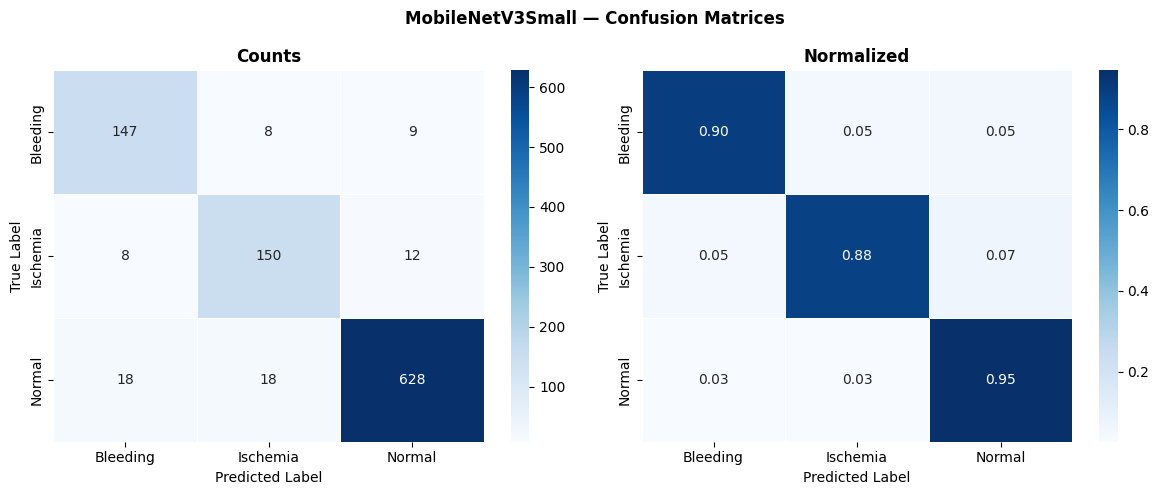


  Evaluating: MobileNetV2
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)


2026-05-29 09:39:07.362606: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-05-29 09:39:12.403755: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


  Accuracy    : 94.39%
  Sensitivity : 92.71%
  Specificity : 97.04%
  Precision   : 91.02%
  F1-Score    : 91.83%
  AUC (macro) : 0.9907
  AUC per class:
    Bleeding    : 0.9919
    Ischemia    : 0.9859
    Normal      : 0.9942

  Classification Report:
              precision    recall  f1-score   support

    Bleeding       0.90      0.91      0.91       164
    Ischemia       0.85      0.91      0.88       170
      Normal       0.98      0.96      0.97       664

    accuracy                           0.94       998
   macro avg       0.91      0.93      0.92       998
weighted avg       0.95      0.94      0.94       998



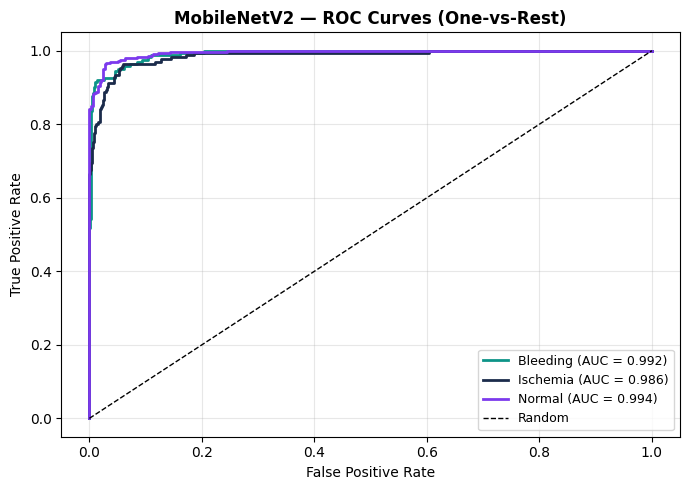

Saved: MobileNetV2_roc.png


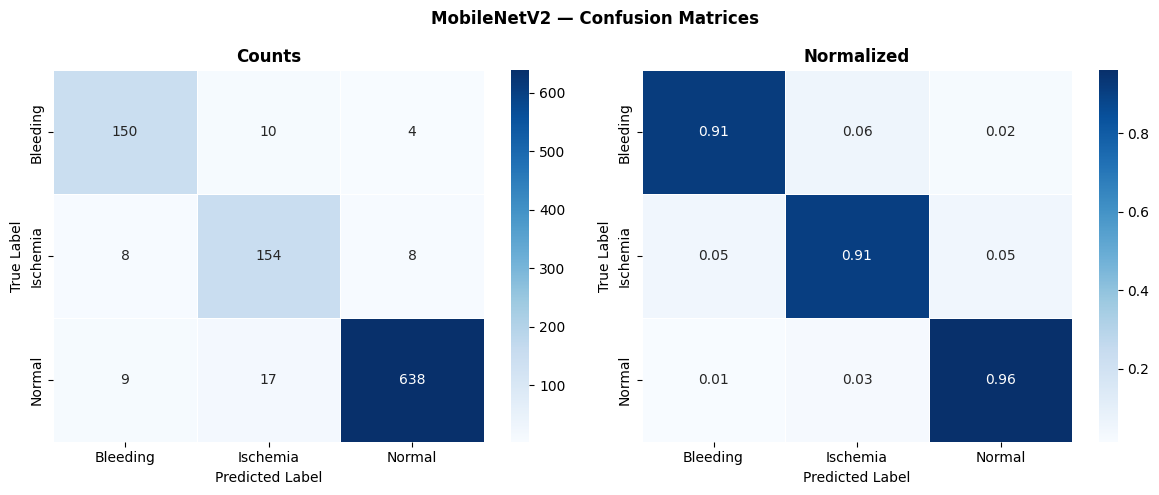


  Evaluating: EfficientNetB0
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)


2026-05-29 09:40:44.513796: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-05-29 09:40:49.603846: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


  Accuracy    : 94.19%
  Sensitivity : 91.99%
  Specificity : 96.24%
  Precision   : 92.18%
  F1-Score    : 92.04%
  AUC (macro) : 0.9888
  AUC per class:
    Bleeding    : 0.9896
    Ischemia    : 0.9887
    Normal      : 0.9879

  Classification Report:
              precision    recall  f1-score   support

    Bleeding       0.94      0.88      0.91       164
    Ischemia       0.87      0.91      0.89       170
      Normal       0.96      0.96      0.96       664

    accuracy                           0.94       998
   macro avg       0.92      0.92      0.92       998
weighted avg       0.94      0.94      0.94       998



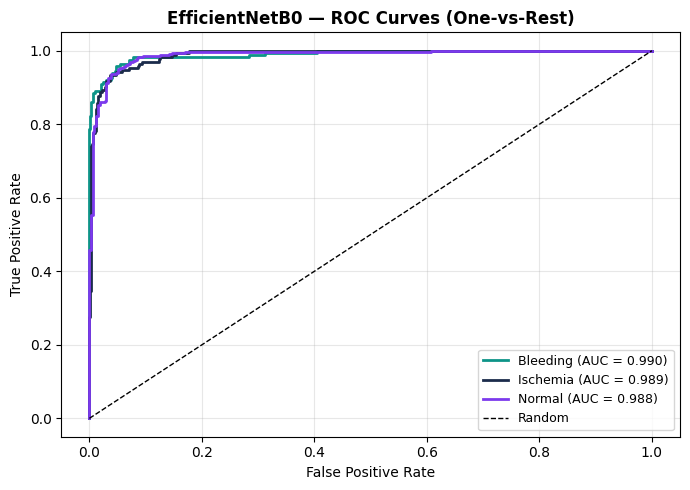

Saved: EfficientNetB0_roc.png


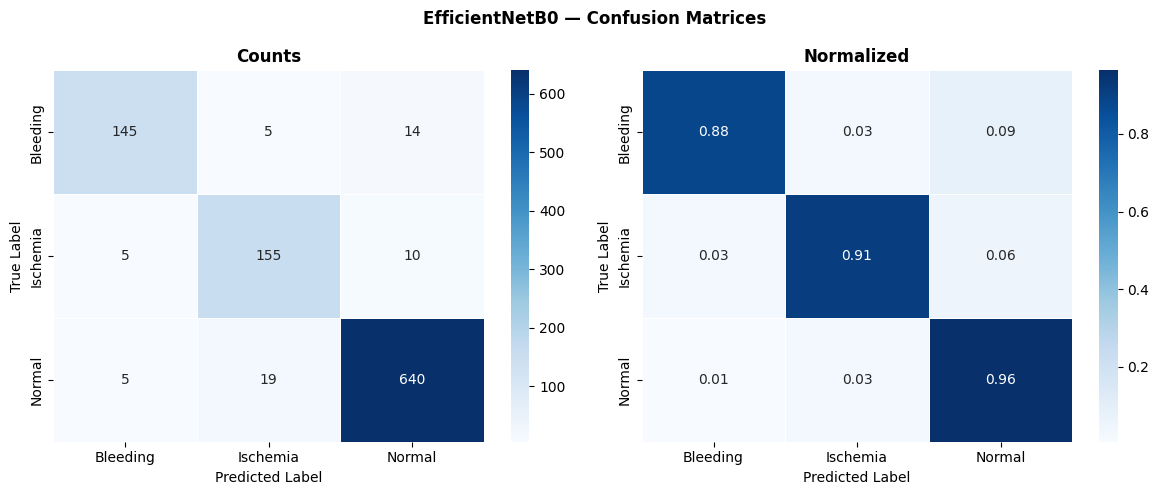

In [14]:
# CELL 9 — RUN EVALUATION ON ALL MODELS
# It shares NO images with the val set used during training / early stopping.

all_metrics = {}

for model_name, model in trained_models.items():
    print("\n" + "=" * 55)
    print(f"  Evaluating: {model_name}")
    print("=" * 55)

    preprocess_fn = MODEL_CONFIGS[model_name]
    _, _, test_gen = build_generators(preprocess_fn)

    metrics, y_true, y_pred, y_probs = evaluate_model(
        model, test_gen, CLASS_NAMES_SORTED
    )
    all_metrics[model_name] = metrics

    print(f"\n  Accuracy    : {metrics['Accuracy']}%")
    print(f"  Sensitivity : {metrics['Sensitivity']}%")
    print(f"  Specificity : {metrics['Specificity']}%")
    print(f"  Precision   : {metrics['Precision']}%")
    print(f"  F1-Score    : {metrics['F1-Score']}%")
    print(f"  AUC (macro) : {metrics['AUC']}")
    print(f"  AUC per class:")
    for cls, auc_val in metrics['AUC_per_class'].items():
        print(f"    {cls:<12}: {auc_val}")

    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES_SORTED,
                                zero_division=0))

    # ROC curves per class
    y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES_SORTED))))
    fig, ax    = plt.subplots(figsize=(7, 5))
    colors     = ["#0D9488", "#1B2B4B", "#7C3AED"]

    for i, (cls, color) in enumerate(zip(CLASS_NAMES_SORTED, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        cls_auc     = roc_auc_score(y_true_bin[:, i], y_probs[:, i])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{cls} (AUC = {cls_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} — ROC Curves (One-vs-Rest)", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{model_name}_roc.png", dpi=150)
    plt.show()
    print(f"Saved: {model_name}_roc.png")

    plot_confusion_matrix(y_true, y_pred, CLASS_NAMES_SORTED, model_name)



  RESULTS — Brain Stroke CT Classification  (test set, 15% held-out)
           Model Parameters  Accuracy  Sensitivity  Specificity  Precision  F1-Score    AUC
  EfficientNetB0      ~5.3M     94.19        91.99        96.24      92.18     92.04 0.9888
     MobileNetV2      ~3.4M     94.39        92.71        97.04      91.02     91.83 0.9907
MobileNetV3Small      ~2.5M     92.69        90.82        95.82      88.99     89.87 0.9832

  Per-class AUC (One-vs-Rest):
           Model  AUC_Bleeding  AUC_Ischemia  AUC_Normal
MobileNetV3Small        0.9850        0.9810      0.9836
     MobileNetV2        0.9919        0.9859      0.9942
  EfficientNetB0        0.9896        0.9887      0.9879

Saved: results_table.csv
Saved: per_class_auc.csv


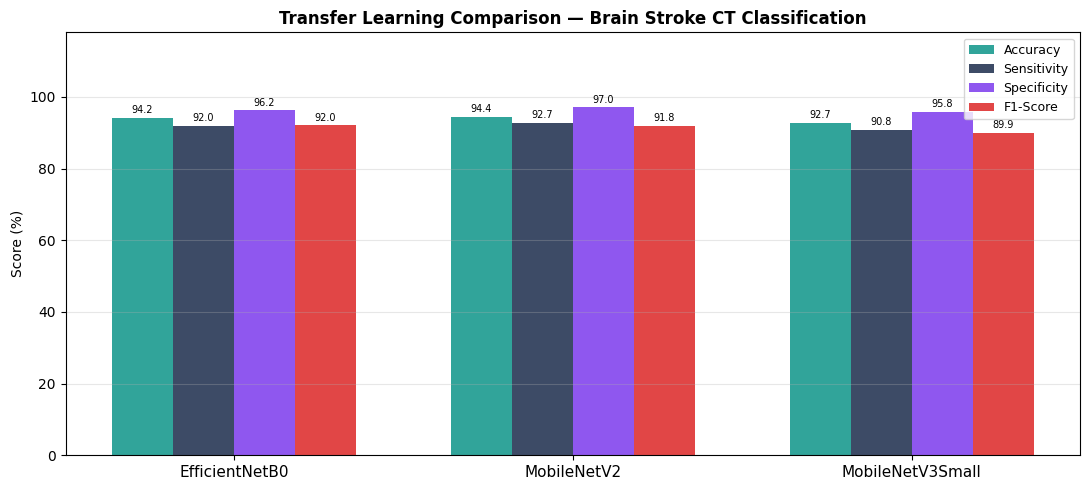

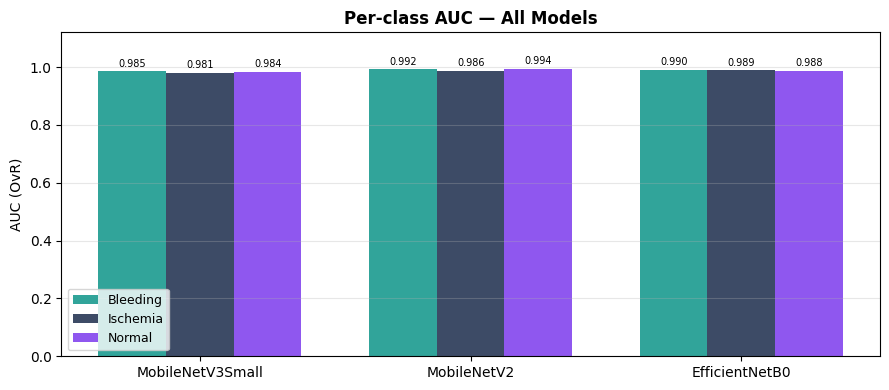

Saved: per_class_auc_chart.png


In [15]:
# CELL 10 — RESULTS TABLE
# Build main metrics DataFrame
results_df = pd.DataFrame({
    model: {k: v for k, v in m.items() if k != "AUC_per_class"}
    for model, m in all_metrics.items()
}).T.reset_index().rename(columns={"index": "Model"})

param_counts = {
    "MobileNetV3Small" : "~2.5M",
    "MobileNetV2"      : "~3.4M",
    "EfficientNetB0"   : "~5.3M",
}
results_df["Parameters"] = results_df["Model"].map(param_counts)
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("  RESULTS — Brain Stroke CT Classification  (test set, 15% held-out)")
print("=" * 80)
print(results_df[[
    "Model", "Parameters", "Accuracy", "Sensitivity",
    "Specificity", "Precision", "F1-Score", "AUC"
]].to_string(index=False))
print("=" * 80)

# Per-class AUC table
print("\n  Per-class AUC (One-vs-Rest):")
auc_rows = []
for model_name, m in all_metrics.items():
    row = {"Model": model_name}
    row.update({f"AUC_{cls}": v for cls, v in m["AUC_per_class"].items()})
    auc_rows.append(row)
auc_df = pd.DataFrame(auc_rows)
print(auc_df.to_string(index=False))

# Save
results_df.to_csv(f"{SAVE_DIR}/results_table.csv", index=False)
auc_df.to_csv(f"{SAVE_DIR}/per_class_auc.csv", index=False)
print(f"\nSaved: results_table.csv")
print(f"Saved: per_class_auc.csv")

# Grouped bar chart
metrics_to_plot = ["Accuracy", "Sensitivity", "Specificity", "F1-Score"]
colors  = ["#0D9488", "#1B2B4B", "#7C3AED", "#DC2626"]
x       = np.arange(len(results_df))
width   = 0.18
offsets = np.linspace(-width * 1.5, width * 1.5, len(metrics_to_plot))

fig, ax = plt.subplots(figsize=(11, 5))
for color, metric, offset in zip(colors, metrics_to_plot, offsets):
    bars = ax.bar(x + offset, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.1f", fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 118)
ax.set_title("Transfer Learning Comparison — Brain Stroke CT Classification",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/results_comparison.png", dpi=150)
plt.show()

# Per-class AUC bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x2      = np.arange(len(auc_df))
cls_cols = [c for c in auc_df.columns if c.startswith("AUC_")]
w2       = 0.25
offsets2 = np.linspace(-w2, w2, len(cls_cols))
colors2  = ["#0D9488", "#1B2B4B", "#7C3AED"]

for col, offset, color in zip(cls_cols, offsets2, colors2):
    bars = ax.bar(x2 + offset, auc_df[col], w2,
                  label=col.replace("AUC_", ""), color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x2)
ax.set_xticklabels(auc_df["Model"], fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("AUC (OvR)")
ax.set_title("Per-class AUC — All Models", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/per_class_auc_chart.png", dpi=150)
plt.show()
print("Saved: per_class_auc_chart.png")


  EFFICIENCY EVALUATION — per-model complexity metrics

[MobileNetV3Small]
  Total params      : 1,271,412  (1.27 M)
  Trainable params  : 1,128,564
  File size         : 14.8 MB
  FLOPs             : 109,709,056  (0.11 GFLOPs)


2026-05-29 09:42:22.055178: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Inference latency : 166.77 ± 7.07 ms  (n=100, batch=1)
  Est. GPU-hours    : 0.000 h  (T4 @8.1 TFLOPS, 65 epochs)

[MobileNetV2]
  Total params      : 2,953,540  (2.95 M)
  Trainable params  : 2,760,196
  File size         : 34.6 MB
  FLOPs             : 590,415,104  (0.59 GFLOPs)


2026-05-29 09:42:41.190183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Inference latency : 159.52 ± 5.96 ms  (n=100, batch=1)
  Est. GPU-hours    : 0.001 h  (T4 @8.1 TFLOPS, 65 epochs)

[EfficientNetB0]
  Total params      : 4,745,127  (4.75 M)
  Trainable params  : 3,923,712
  File size         : 51.3 MB
  FLOPs             : 732,864,768  (0.73 GFLOPs)


2026-05-29 09:43:00.179391: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Inference latency : 305.82 ± 9.43 ms  (n=100, batch=1)
  Est. GPU-hours    : 0.001 h  (T4 @8.1 TFLOPS, 65 epochs)

  EFFICIENCY SUMMARY TABLE
           Model  Params (M)  Size (MB)  GFLOPs  Latency (ms)  GPU-hours (est)
MobileNetV3Small        1.27       14.8    0.11 166.77 ± 7.07            0.000
     MobileNetV2        2.95       34.6    0.59 159.52 ± 5.96            0.001
  EfficientNetB0        4.75       51.3    0.73 305.82 ± 9.43            0.001

Saved: efficiency_table.csv

  COMBINED: performance + efficiency
           Model  Params (M)  GFLOPs  Latency (ms)  Accuracy  F1-Score    AUC
  EfficientNetB0        4.75    0.73 305.82 ± 9.43     94.19     92.04 0.9888
     MobileNetV2        2.95    0.59 159.52 ± 5.96     94.39     91.83 0.9907
MobileNetV3Small        1.27    0.11 166.77 ± 7.07     92.69     89.87 0.9832
Saved: results_efficiency_merged.csv


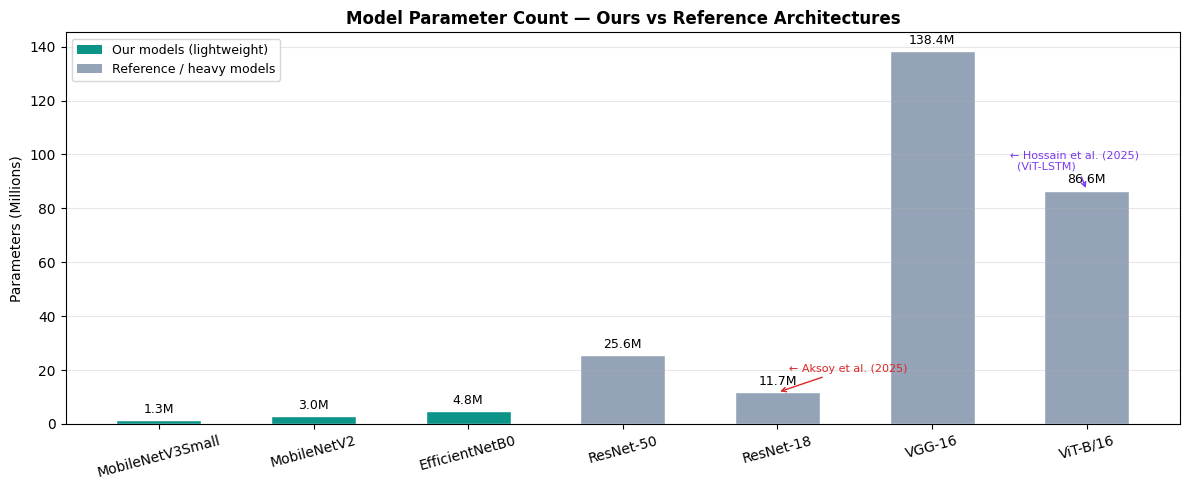

Saved: efficiency_params_comparison.png


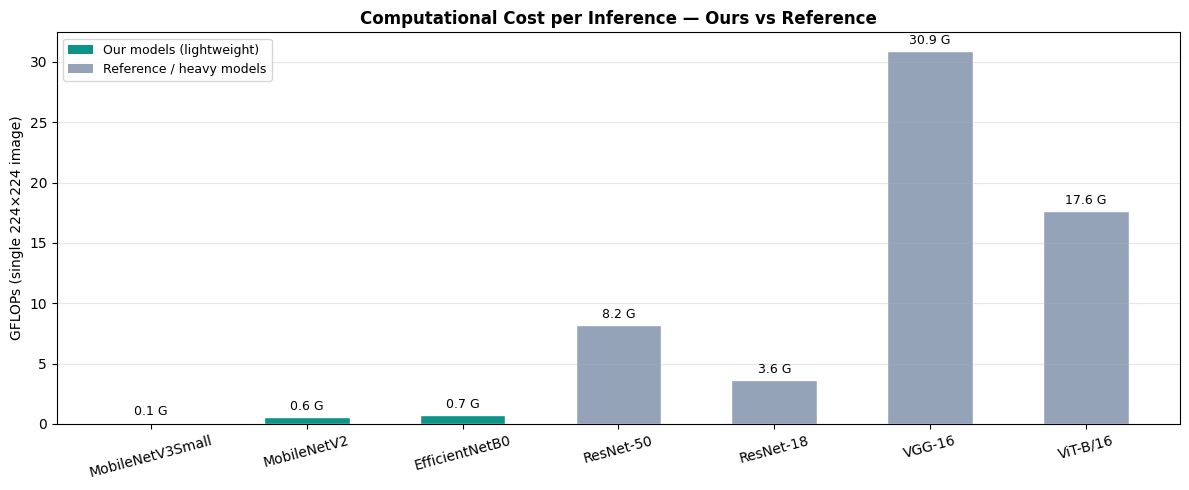

Saved: efficiency_flops_comparison.png


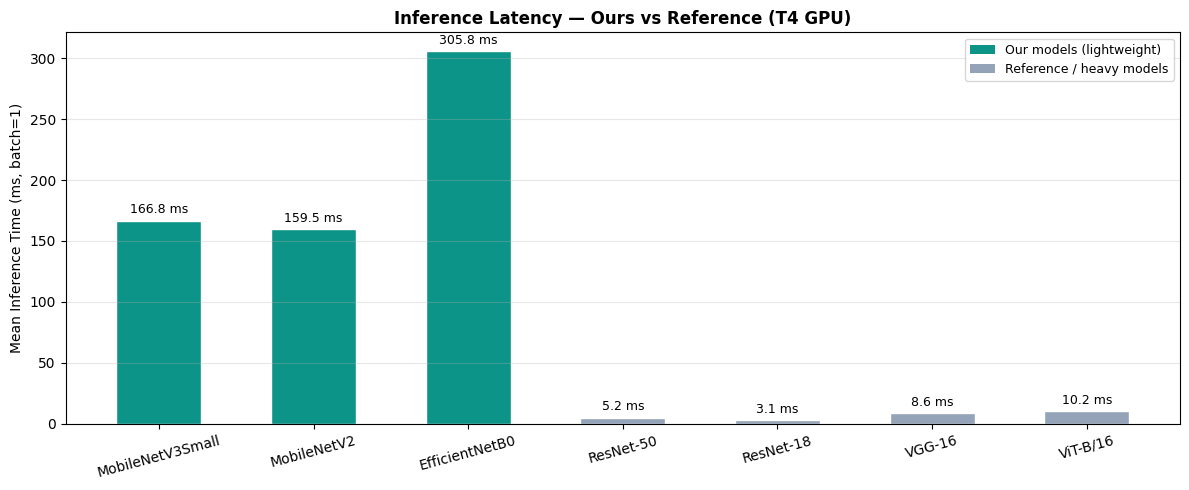

Saved: efficiency_latency_comparison.png

✓ Efficiency evaluation complete.
  Outputs: efficiency_table.csv | efficiency_params_comparison.png
           efficiency_flops_comparison.png | efficiency_latency_comparison.png


In [16]:
#10b — EFFICIENCY EVALUATION
#
# Measures for each model:
#   - Parameters (trainable + total)
#   - Model file size on disk (.keras checkpoint)
#   - FLOPs (floating-point operations per single inference)
#   - Inference latency (mean ± std over 100 warm runs, batch=1)
#   - Estimated Kaggle T4 GPU-hours
#
# FLOPs are computed with tf.profiler.experimental (TF ≥ 2.7).
# Fallback: manual MACs estimation via layer-by-layer traversal.

import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ── Helper: count FLOPs via TF concrete function profiling ────────────────────
def get_flops(model, input_shape=(1, 224, 224, 3)):
    """
    Returns total FLOPs (multiply-adds counted as 2 ops each).
    Uses tf.profiler on a @tf.function concrete trace.
    Falls back to a layer-scan estimate if profiler is unavailable.
    """
    try:
        @tf.function
        def forward(x):
            return model(x, training=False)

        concrete = forward.get_concrete_function(
            tf.TensorSpec(input_shape, dtype=tf.float32)
        )
        frozen   = convert_variables_to_constants_v2(concrete)
        graph    = frozen.graph

        run_meta = tf.compat.v1.RunMetadata()
        opts     = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops    = tf.compat.v1.profiler.profile(
            graph=graph, run_meta=run_meta, cmd="op", options=opts
        )
        return flops.total_float_ops

    except Exception:
        # ── Fallback: estimate MACs from Conv2D and Dense layers ──────────────
        total_macs = 0
        for layer in model.layers:
            cfg = layer.get_config()
            if isinstance(layer, tf.keras.layers.Conv2D):
                try:
                    out_shape = layer.output.shape   # (None, H, W, F_out)
                    H, W      = out_shape[1], out_shape[2]
                    F_out     = out_shape[3]
                    kH, kW    = cfg["kernel_size"]
                    F_in      = layer.input.shape[-1]
                    macs      = H * W * F_out * kH * kW * F_in
                    total_macs += int(macs)
                except Exception:
                    pass
            elif isinstance(layer, tf.keras.layers.Dense):
                try:
                    units = cfg["units"]
                    in_f  = layer.input.shape[-1]
                    total_macs += int(units * in_f)
                except Exception:
                    pass
        return total_macs * 2   # MACs → FLOPs (each MAC = 1 mul + 1 add)


# ── Helper: measure inference latency ─────────────────────────────────────────
def measure_latency(model, n_warmup=10, n_runs=100, img_size=IMG_SIZE):
    """
    Returns (mean_ms, std_ms) for single-image inference.
    Warm-up runs excluded from statistics.
    """
    dummy = np.random.rand(1, img_size[0], img_size[1], 3).astype(np.float32)
    _ = model.predict(dummy, verbose=0)                  # initial compile pass

    # Warm-up
    for _ in range(n_warmup):
        model(dummy, training=False)

    # Timed runs
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model(dummy, training=False)
        times.append((time.perf_counter() - t0) * 1000)  # ms

    return float(np.mean(times)), float(np.std(times))


# ── Helper: read saved model file size ────────────────────────────────────────
def get_model_size_mb(model_name, phase=2, save_dir=SAVE_DIR):
    """Returns size in MB of the best Phase-2 checkpoint."""
    path = os.path.join(save_dir, f"{model_name}_phase{phase}_best.keras")
    if os.path.exists(path):
        return os.path.getsize(path) / 1e6
    # Try phase 1 fallback
    path1 = os.path.join(save_dir, f"{model_name}_phase1_best.keras")
    if os.path.exists(path1):
        return os.path.getsize(path1) / 1e6
    return None


#Reference data: heavy models for comparison 
# Values from published benchmarks (ImageNet, single 224×224 image, GPU)
REFERENCE_MODELS = {
    "ResNet-50"  : {"params_M": 25.6, "flops_G": 8.2,  "size_mb": 102.0, "latency_ms": 5.2},
    "ResNet-18"  : {"params_M": 11.7, "flops_G": 3.6,  "size_mb":  46.8, "latency_ms": 3.1},
    "VGG-16"     : {"params_M": 138.4,"flops_G": 30.9, "size_mb": 553.0, "latency_ms": 8.6},
    "ViT-B/16"   : {"params_M": 86.6, "flops_G": 17.6, "size_mb": 346.0, "latency_ms":10.2},
}
# Note: Hossain et al. (2025) used a hybrid ViT-LSTM (~86M+ params);
#       Aksoy et al. (2025) used ResNet-18 (~11.7M params).

#  Main evaluation loop
print("=" * 65)
print("  EFFICIENCY EVALUATION — per-model complexity metrics")
print("=" * 65)

efficiency_rows = []

for model_name, model in trained_models.items():
    print(f"\n[{model_name}]")

    # 1. Parameters
    total_params     = model.count_params()
    trainable_params = sum(
        tf.size(w).numpy() for w in model.trainable_weights
    )
    params_M = total_params / 1e6
    print(f"  Total params      : {total_params:,}  ({params_M:.2f} M)")
    print(f"  Trainable params  : {trainable_params:,}")

    # 2. Model file size
    size_mb = get_model_size_mb(model_name)
    if size_mb is not None:
        print(f"  File size         : {size_mb:.1f} MB")
    else:
        print(f"  File size         : not found on disk")

    # 3. FLOPs
    flops      = get_flops(model)
    flops_G    = flops / 1e9
    print(f"  FLOPs             : {flops:,}  ({flops_G:.2f} GFLOPs)")

    # 4. Inference latency
    lat_mean, lat_std = measure_latency(model)
    print(f"  Inference latency : {lat_mean:.2f} ± {lat_std:.2f} ms  (n=100, batch=1)")

    # 5. Estimated GPU-hours on Kaggle T4
    #    T4 throughput ≈ 8.1 TFLOPS FP32
    #    training ≈ 3× forward FLOPs per step (forward + backward + optimizer)
    #    total steps = (train_samples / batch_size) × total_epochs
    total_epochs      = EPOCHS_FROZEN + EPOCHS_FINETUNE
    steps_per_epoch   = len(train_paths) // BATCH_SIZE
    total_steps       = steps_per_epoch * total_epochs
    T4_TFLOPS         = 8.1e12                         # FP32
    train_flops_total = flops * 3 * total_steps        # 3× for backprop
    gpu_hours         = train_flops_total / T4_TFLOPS / 3600
    print(f"  Est. GPU-hours    : {gpu_hours:.3f} h  "
          f"(T4 @8.1 TFLOPS, {total_epochs} epochs)")

    efficiency_rows.append({
        "Model"          : model_name,
        "Params (M)"     : round(params_M, 2),
        "Size (MB)"      : round(size_mb, 1) if size_mb else "—",
        "GFLOPs"         : round(flops_G, 2),
        "Latency (ms)"   : f"{lat_mean:.2f} ± {lat_std:.2f}",
        "GPU-hours (est)": round(gpu_hours, 3),
    })


# Build efficiency DataFrame
eff_df = pd.DataFrame(efficiency_rows)
print("\n" + "=" * 65)
print("  EFFICIENCY SUMMARY TABLE")
print("=" * 65)
print(eff_df.to_string(index=False))

eff_df.to_csv(f"{SAVE_DIR}/efficiency_table.csv", index=False)
print(f"\nSaved: efficiency_table.csv")


# Merge with performance metrics 
if "results_df" in dir():
    merged_df = results_df.merge(eff_df, on="Model", how="left")
    print("\n  COMBINED: performance + efficiency")
    print(merged_df[[
        "Model", "Params (M)", "GFLOPs", "Latency (ms)",
        "Accuracy", "F1-Score", "AUC"
    ]].to_string(index=False))
    merged_df.to_csv(f"{SAVE_DIR}/results_efficiency_merged.csv", index=False)
    print(f"Saved: results_efficiency_merged.csv")


# ── Chart 1: Parameter count comparison (ours vs reference models)
fig, ax = plt.subplots(figsize=(12, 5))

our_names   = [r["Model"]      for r in efficiency_rows]
our_params  = [r["Params (M)"] for r in efficiency_rows]
ref_names   = list(REFERENCE_MODELS.keys())
ref_params  = [v["params_M"]   for v in REFERENCE_MODELS.values()]

all_names   = our_names + ref_names
all_params  = our_params + ref_params
colors_bar  = (
    ["#0D9488"] * len(our_names) +    # teal = our models
    ["#94A3B8"] * len(ref_names)       # grey = reference
)

bars = ax.bar(all_names, all_params, color=colors_bar, edgecolor="white",
              width=0.55)
ax.bar_label(bars, fmt="%.1fM", padding=3, fontsize=9)

# Annotate reference papers
for ref_name, ref_info in REFERENCE_MODELS.items():
    if ref_name == "ResNet-18":
        ax.annotate("← Aksoy et al. (2025)",
                    xy=(ref_names.index(ref_name) + len(our_names),
                        ref_info["params_M"]),
                    xytext=(8, 15), textcoords="offset points",
                    fontsize=8, color="#DC2626",
                    arrowprops=dict(arrowstyle="->", color="#DC2626", lw=1))
    if ref_name == "ViT-B/16":
        ax.annotate("← Hossain et al. (2025)\n  (ViT-LSTM)",
                    xy=(ref_names.index(ref_name) + len(our_names),
                        ref_info["params_M"]),
                    xytext=(-55, 15), textcoords="offset points",
                    fontsize=8, color="#7C3AED",
                    arrowprops=dict(arrowstyle="->", color="#7C3AED", lw=1))

ax.set_ylabel("Parameters (Millions)")
ax.set_title("Model Parameter Count — Ours vs Reference Architectures",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#0D9488", label="Our models (lightweight)"),
    Patch(facecolor="#94A3B8", label="Reference / heavy models"),
]
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/efficiency_params_comparison.png", dpi=150)
plt.show()
print("Saved: efficiency_params_comparison.png")


#Chart 2: FLOPs comparison 
fig, ax = plt.subplots(figsize=(12, 5))

our_flops = [r["GFLOPs"] for r in efficiency_rows]
ref_flops = [v["flops_G"] for v in REFERENCE_MODELS.values()]

all_flops = our_flops + ref_flops
bars2 = ax.bar(all_names, all_flops, color=colors_bar, edgecolor="white",
               width=0.55)
ax.bar_label(bars2, fmt="%.1f G", padding=3, fontsize=9)
ax.set_ylabel("GFLOPs (single 224×224 image)")
ax.set_title("Computational Cost per Inference — Ours vs Reference",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/efficiency_flops_comparison.png", dpi=150)
plt.show()
print("Saved: efficiency_flops_comparison.png")


#Chart 3: Latency per image 
fig, ax = plt.subplots(figsize=(12, 5))

our_lat  = [float(r["Latency (ms)"].split(" ")[0]) for r in efficiency_rows]
ref_lat  = [v["latency_ms"] for v in REFERENCE_MODELS.values()]
all_lat  = our_lat + ref_lat

bars3 = ax.bar(all_names, all_lat, color=colors_bar, edgecolor="white",
               width=0.55)
ax.bar_label(bars3, fmt="%.1f ms", padding=3, fontsize=9)
ax.set_ylabel("Mean Inference Time (ms, batch=1)")
ax.set_title("Inference Latency — Ours vs Reference (T4 GPU)",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/efficiency_latency_comparison.png", dpi=150)
plt.show()
print("Saved: efficiency_latency_comparison.png")

print("\n✓ Efficiency evaluation complete.")
print(f"  Outputs: efficiency_table.csv | efficiency_params_comparison.png")
print(f"           efficiency_flops_comparison.png | efficiency_latency_comparison.png")

In [17]:
# CELL 11 — GRAD-CAM++ IMPLEMENTATION
def make_gradcam_plus_plus(img_array, model, last_conv_layer_name,
                            pred_index=None):
    """
    Grad-CAM++ for softmax multiclass models.
      - Normalises the raw CAM to [0, 1] using min-max scaling.
      - Then applies HEATMAP_THRESHOLD to suppress diffuse background activations.
    Returns (cam float[0,1], pred_index).
    """
    grad_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_score = predictions[:, pred_index]
    grads        = tape.gradient(class_score, conv_outputs)
    conv_outputs = conv_outputs[0]
    grads        = grads[0]
    relu_grads     = tf.nn.relu(grads)
    grad_sq        = relu_grads ** 2
    grad_cu        = relu_grads ** 3
    activation_sum = tf.reduce_sum(conv_outputs, axis=[0, 1], keepdims=True)
    denom   = 2.0 * grad_sq + activation_sum * grad_cu
    denom   = tf.where(tf.equal(denom, 0.0), tf.ones_like(denom), denom)
    alpha   = grad_sq / denom
    weights = tf.reduce_sum(alpha * relu_grads, axis=[0, 1])
    cam = tf.reduce_sum(weights[tf.newaxis, tf.newaxis, :] * conv_outputs, axis=-1)
    cam = tf.nn.relu(cam).numpy()
    # STEP 1: Normalise to [0, 1]
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)
    # STEP 2: HEATMAP_THRESHOLD
    HEATMAP_THRESHOLD = 0.40
    cam = np.where(cam >= HEATMAP_THRESHOLD, cam, 0.0)
    # STEP 3: Re-normalise so hotspot spans [0, 1]
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    return cam, pred_index

def overlay_cam(img_original, cam, alpha=0.40):
    """
    Overlays the thresholded Grad-CAM++ cam onto the CT image.
      - Uses a binary mask: colormap blended ONLY where cam > 0.
      - alpha=0.40 keeps the overlay subtle but visible.
    """
    cam_resized = cv2.resize(cam, (img_original.shape[1], img_original.shape[0]))
    cam_uint8   = np.uint8(255 * cam_resized)
    cam_colored = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    cam_rgb     = cv2.cvtColor(cam_colored, cv2.COLOR_BGR2RGB)
    mask   = cam_resized > 0
    result = img_original.copy().astype(np.float32)
    result[mask] = (
        (1 - alpha) * img_original[mask].astype(np.float32)
        + alpha     * cam_rgb[mask].astype(np.float32)
    )
    return np.clip(result, 0, 255).astype(np.uint8)

print("Grad-CAM++ functions ready.")
print(f"  HEATMAP_THRESHOLD = 0.40  (applied after normalisation)")
print("  overlay_cam       : colormap applied only over the lesion hotspot")

Grad-CAM++ functions ready.
  HEATMAP_THRESHOLD = 0.40  (applied after normalisation)
  overlay_cam       : colormap applied only over the lesion hotspot


In [18]:
# CELL 11b — GRAD-CAM++ POUR EFFICIENTNETB0
HEATMAP_THRESHOLD = 0.40

def make_gradcam_plus_plus(img_array, model, last_conv_layer_name,
                            pred_index=None):
    grad_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_score = predictions[:, pred_index]
    grads        = tape.gradient(class_score, conv_outputs)
    conv_outputs = conv_outputs[0]
    grads        = grads[0]
    relu_grads     = tf.nn.relu(grads)
    grad_sq        = relu_grads ** 2
    grad_cu        = relu_grads ** 3
    activation_sum = tf.reduce_sum(conv_outputs, axis=[0, 1], keepdims=True)
    denom   = 2.0 * grad_sq + activation_sum * grad_cu
    denom   = tf.where(tf.equal(denom, 0.0), tf.ones_like(denom), denom)
    alpha   = grad_sq / denom
    weights = tf.reduce_sum(alpha * relu_grads, axis=[0, 1])
    cam = tf.reduce_sum(weights[tf.newaxis, tf.newaxis, :] * conv_outputs, axis=-1)
    cam = tf.nn.relu(cam).numpy()
    # STEP 1: Normalise [0, 1]
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)
    # STEP 2: Threshold
    cam = np.where(cam >= HEATMAP_THRESHOLD, cam, 0.0)
    # STEP 3: Re-normalise
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max > cam_min:
        cam = (cam - cam_min) / (cam_max - cam_min)
    return cam, pred_index

def overlay_cam(img_original, cam, alpha=0.40):
    cam_resized = cv2.resize(cam, (img_original.shape[1], img_original.shape[0]))
    cam_uint8   = np.uint8(255 * cam_resized)
    cam_colored = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    cam_rgb     = cv2.cvtColor(cam_colored, cv2.COLOR_BGR2RGB)
    mask   = cam_resized > 0
    result = img_original.copy().astype(np.float32)
    result[mask] = (
        (1 - alpha) * img_original[mask].astype(np.float32)
        + alpha     * cam_rgb[mask].astype(np.float32)
    )
    return np.clip(result, 0, 255).astype(np.uint8)

print("Grad-CAM++ ready for EfficientNetB0")
print(f"  Last conv layer  : {LAST_CONV_LAYER['EfficientNetB0']}")  # top_activation
print(f"  HEATMAP_THRESHOLD: {HEATMAP_THRESHOLD}")

Grad-CAM++ ready for EfficientNetB0
  Last conv layer  : att_map
  HEATMAP_THRESHOLD: 0.4


Applying Grad-CAM++ to: EfficientNetB0
  Last conv layer : att_map
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)


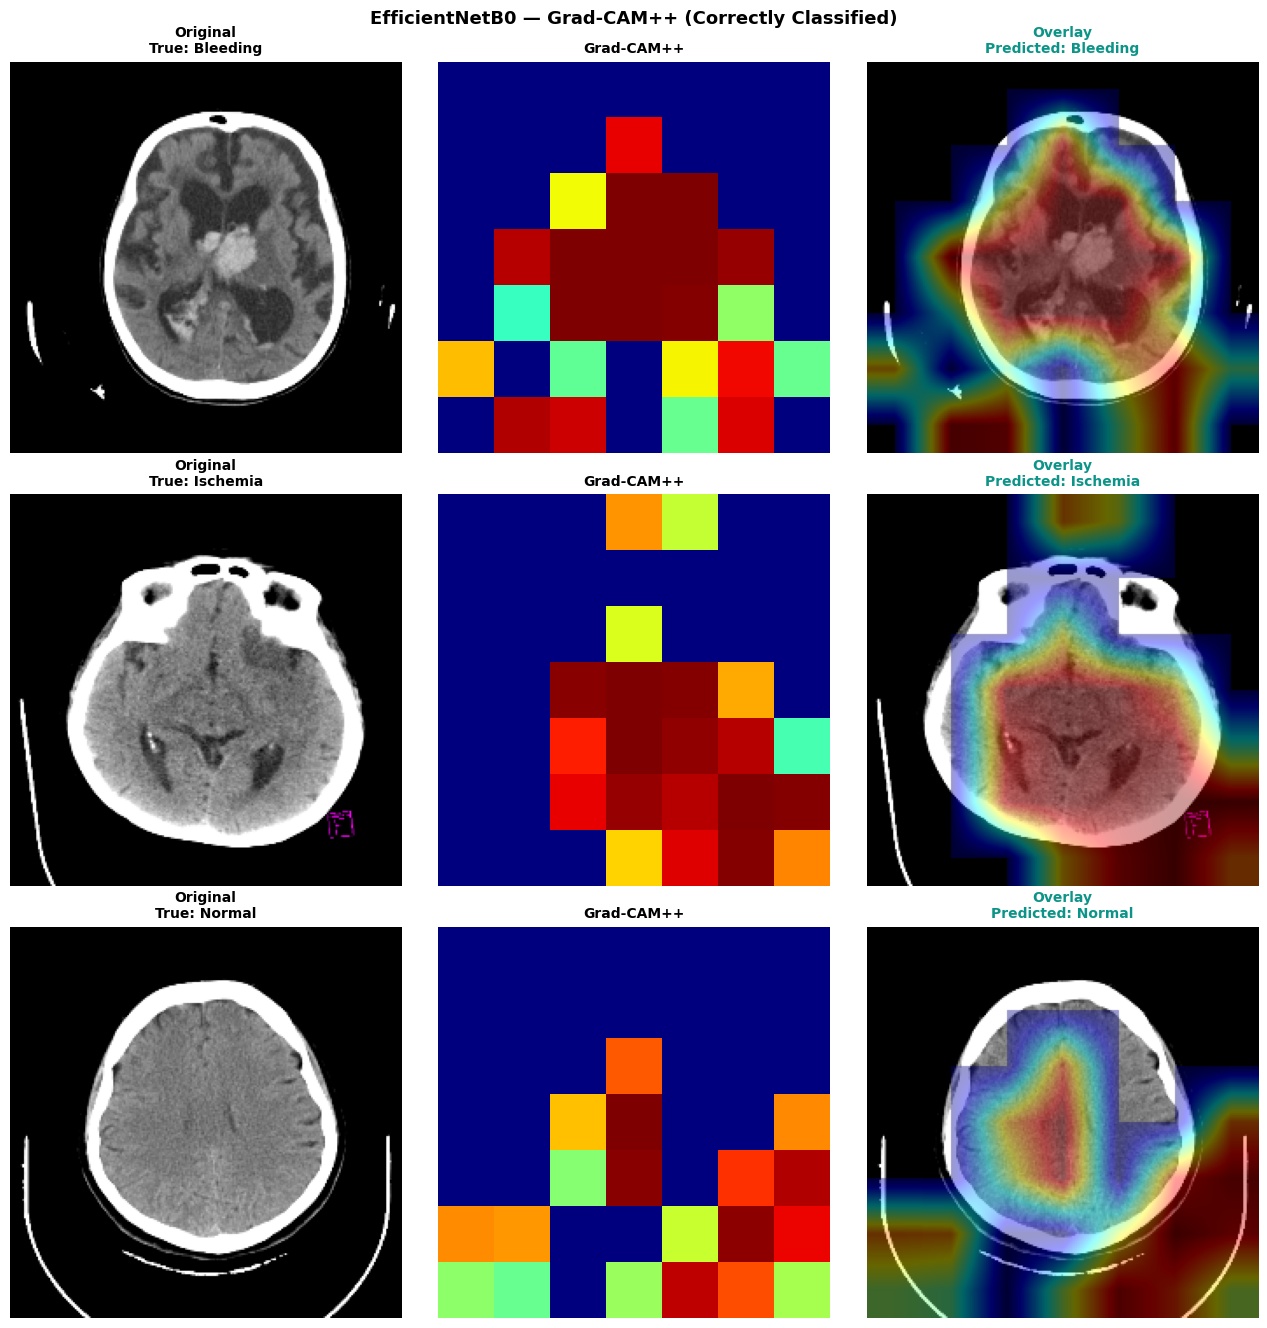

Saved: /kaggle/working/EfficientNetB0_gradcam_correct.png


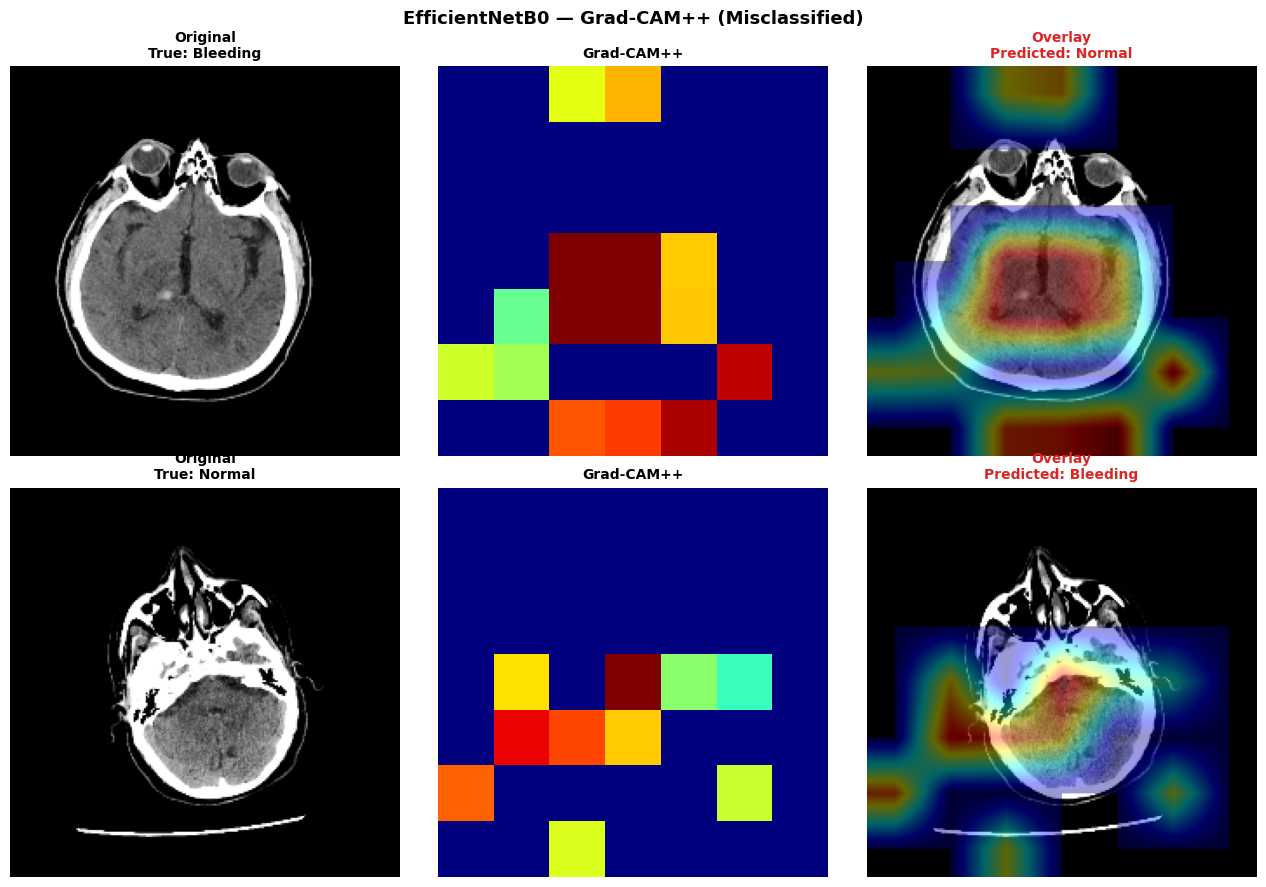

Saved: /kaggle/working/EfficientNetB0_gradcam_wrong.png


In [19]:
# CELL 12 — GRAD-CAM++ VISUALIZATION
best_model_name = results_df.iloc[0]["Model"]
best_model      = trained_models[best_model_name]
best_last_conv  = last_conv_layers[best_model_name]
best_preprocess = MODEL_CONFIGS[best_model_name]

print(f"Applying Grad-CAM++ to: {best_model_name}")
print(f"  Last conv layer : {best_last_conv}")

_, _, test_gen = build_generators(best_preprocess)
test_gen.reset()

IDX_TO_CLASS = {i: cls for i, cls in enumerate(CLASS_NAMES_SORTED)}
samples_per_class = {c: {"correct": None, "wrong": None}
                     for c in CLASS_NAMES_SORTED}

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    true_idx   = int(np.argmax(y_batch[0]))
    true_label = IDX_TO_CLASS[true_idx]
    cam, pred_idx = make_gradcam_plus_plus(
        x_batch, best_model, best_last_conv)
    pred_label = IDX_TO_CLASS[pred_idx]
    filepath = test_gen.filepaths[i]
    raw_img  = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    raw_img  = cv2.resize(raw_img, IMG_SIZE)
    slot = "correct" if true_label == pred_label else "wrong"
    if samples_per_class[true_label][slot] is None:
        samples_per_class[true_label][slot] = (
            raw_img, x_batch, cam, true_label, pred_label)
    if all(s["correct"] is not None for s in samples_per_class.values()):
        break

def visualize_gradcam(samples_per_class, model_name,
                       sample_type="correct", save_dir=SAVE_DIR):
    available = [(cls, info[sample_type])
                 for cls, info in samples_per_class.items()
                 if info[sample_type] is not None]
    if not available:
        print(f"No {sample_type} samples found.")
        return
    n_rows = len(available)
    fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    status_str = "Correctly Classified" if sample_type == "correct" else "Misclassified"
    fig.suptitle(f"{model_name} — Grad-CAM++ ({status_str})",
                 fontweight="bold", fontsize=13)
    for row_idx, (cls, sample) in enumerate(available):
        raw_img, x_batch, cam, true_label, pred_label = sample
        overlay = overlay_cam(raw_img, cam, alpha=0.40)         # ← overlay_cam + alpha réduit
        color   = "#0D9488" if true_label == pred_label else "#DC2626"
        for col_idx, (img, title, cmap) in enumerate([
            (raw_img, f"Original\nTrue: {true_label}", None),
            (cam,     "Grad-CAM++", "jet"),                     # ← "cam" pas "heatmap"
            (overlay, f"Overlay\nPredicted: {pred_label}", None),
        ]):
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap=cmap)
            ax.set_title(title, fontsize=10,
                         color=color if col_idx == 2 else "black",
                         fontweight="bold")
            ax.axis("off")
    plt.tight_layout()
    fname = f"{save_dir}/{model_name}_gradcam_{sample_type}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

visualize_gradcam(samples_per_class, best_model_name, "correct")
visualize_gradcam(samples_per_class, best_model_name, "wrong")

Applying Grad-CAM++ to: EfficientNetB0
  Last conv layer : att_map
  BalancedGenerator ready (train only):
    Bleeding    : 765 original  -> 3099 after oversample
    Ischemia    : 791 original  -> 3099 after oversample
    Normal      : 3099 original  -> 3099 after oversample
    Total samples    : 9297
    Batches per epoch: 290
  Train batches/epoch : 290
  Val images          : 997
  Test images         : 998  (held-out, clean)


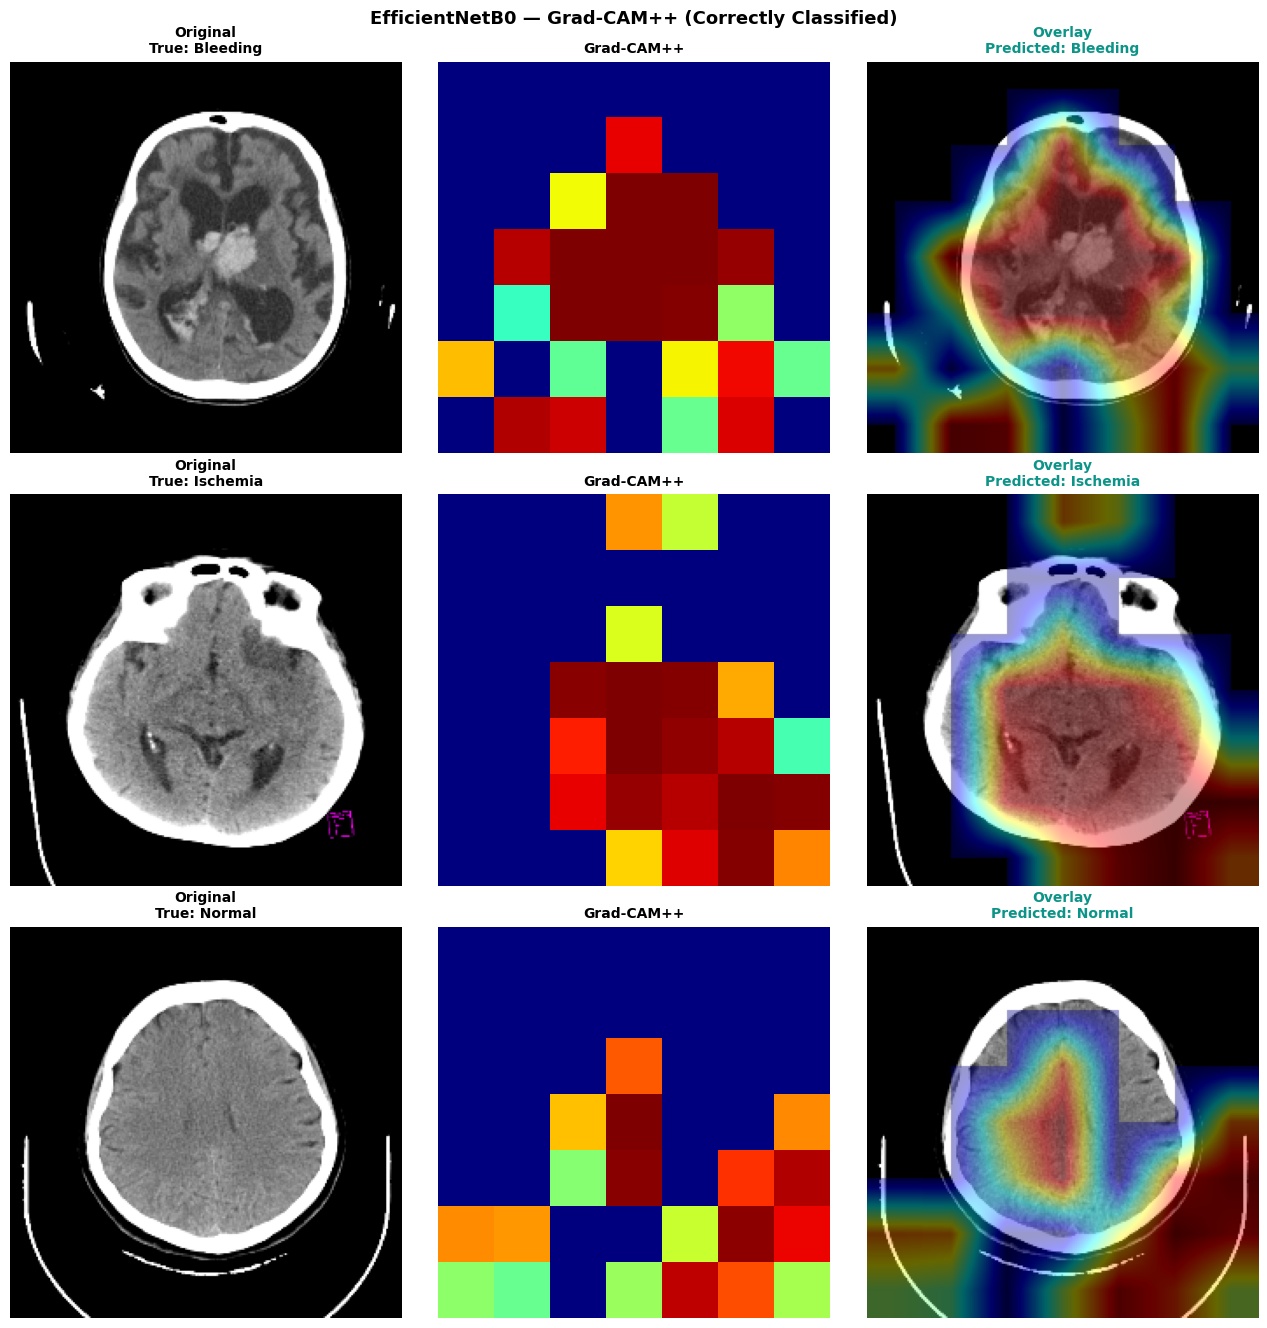

Saved: /kaggle/working/EfficientNetB0_gradcam_correct.png


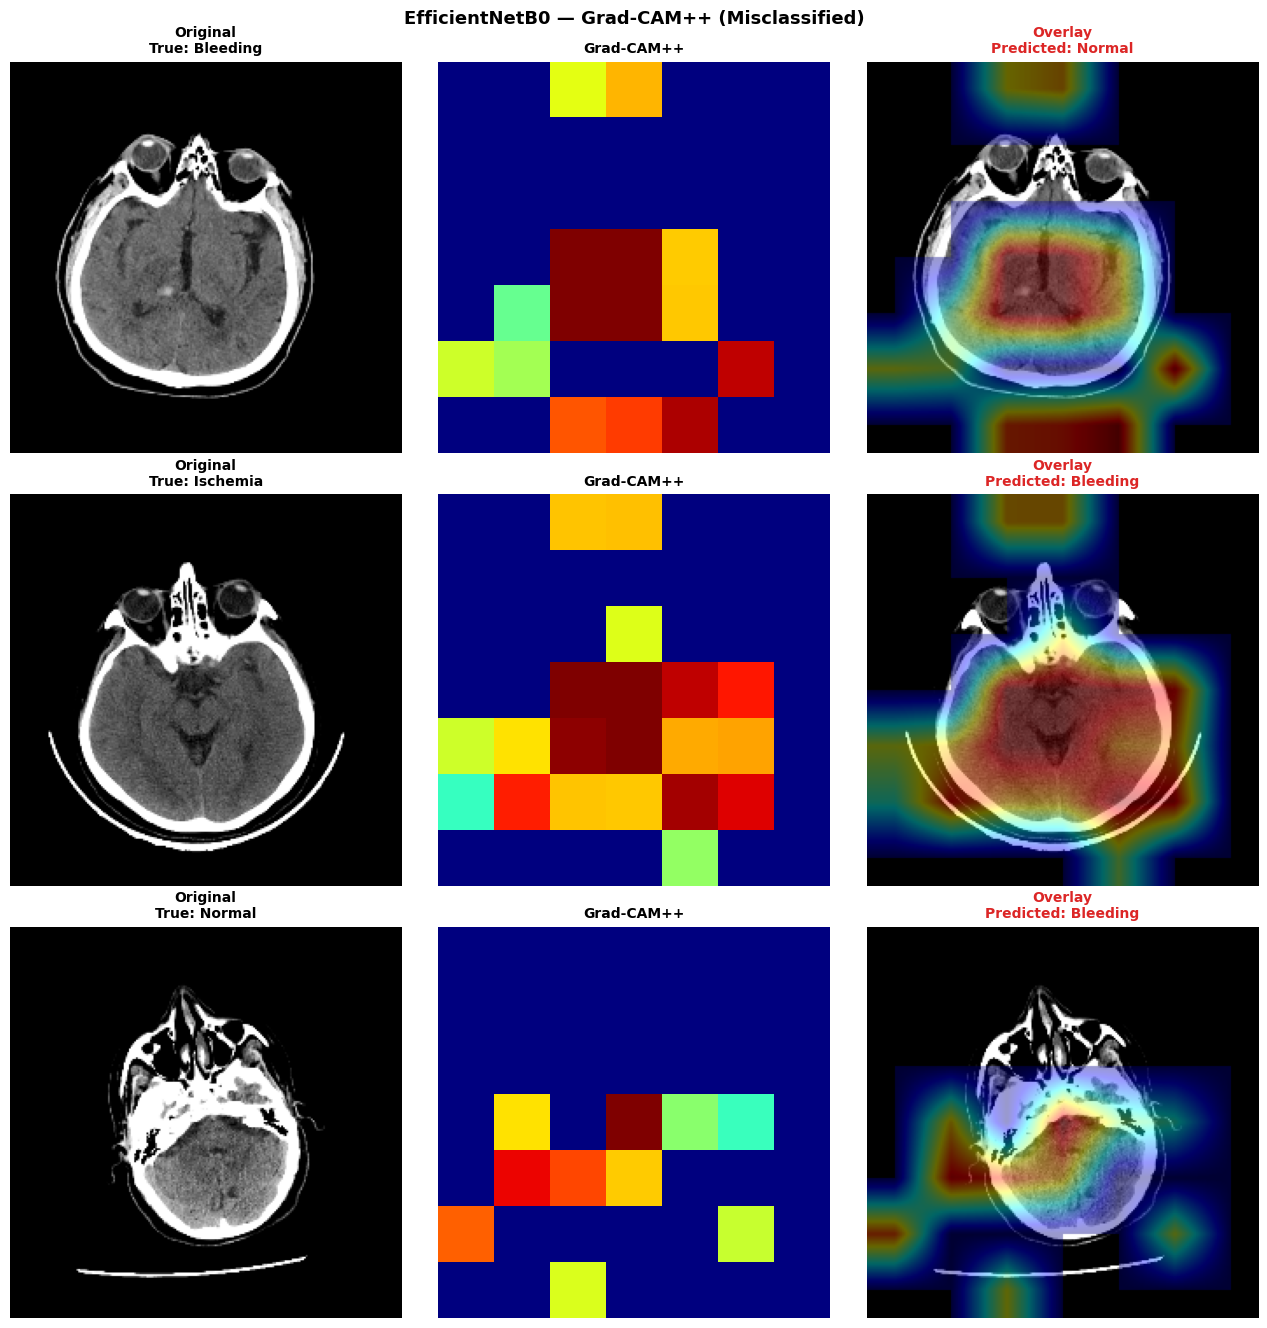

Saved: /kaggle/working/EfficientNetB0_gradcam_wrong.png


In [20]:
# CELL 12b — VISUALISATION GRAD-CAM++ EFFICIENTNETB0
effnet_model     = trained_models["EfficientNetB0"]
effnet_last_conv = LAST_CONV_LAYER["EfficientNetB0"]        # "top_activation"
effnet_preprocess = MODEL_CONFIGS["EfficientNetB0"]

print(f"Applying Grad-CAM++ to: EfficientNetB0")
print(f"  Last conv layer : {effnet_last_conv}")

_, _, test_gen = build_generators(effnet_preprocess)
test_gen.reset()

IDX_TO_CLASS = {i: cls for i, cls in enumerate(CLASS_NAMES_SORTED)}
samples_per_class = {c: {"correct": None, "wrong": None}
                     for c in CLASS_NAMES_SORTED}

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    true_idx   = int(np.argmax(y_batch[0]))
    true_label = IDX_TO_CLASS[true_idx]
    cam, pred_idx = make_gradcam_plus_plus(
        x_batch, effnet_model, effnet_last_conv)
    pred_label = IDX_TO_CLASS[pred_idx]
    filepath = test_gen.filepaths[i]
    raw_img  = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    raw_img  = cv2.resize(raw_img, IMG_SIZE)
    slot = "correct" if true_label == pred_label else "wrong"
    if samples_per_class[true_label][slot] is None:
        samples_per_class[true_label][slot] = (
            raw_img, x_batch, cam, true_label, pred_label)
    if all(s["correct"] is not None and s["wrong"] is not None
           for s in samples_per_class.values()):
        break

def visualize_gradcam(samples_per_class, model_name,
                       sample_type="correct", save_dir=SAVE_DIR):
    available = [(cls, info[sample_type])
                 for cls, info in samples_per_class.items()
                 if info[sample_type] is not None]
    if not available:
        print(f"No {sample_type} samples found.")
        return
    n_rows = len(available)
    fig, axes = plt.subplots(n_rows, 3, figsize=(13, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    status_str = "Correctly Classified" if sample_type == "correct" else "Misclassified"
    fig.suptitle(f"{model_name} — Grad-CAM++ ({status_str})",
                 fontweight="bold", fontsize=13)
    for row_idx, (cls, sample) in enumerate(available):
        raw_img, x_batch, cam, true_label, pred_label = sample
        overlay = overlay_cam(raw_img, cam, alpha=0.40)
        color   = "#0D9488" if true_label == pred_label else "#DC2626"
        for col_idx, (img, title, cmap) in enumerate([
            (raw_img, f"Original\nTrue: {true_label}", None),
            (cam,     "Grad-CAM++",                    "jet"),
            (overlay, f"Overlay\nPredicted: {pred_label}", None),
        ]):
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap=cmap)
            ax.set_title(title, fontsize=10,
                         color=color if col_idx == 2 else "black",
                         fontweight="bold")
            ax.axis("off")
    plt.tight_layout()
    fname = f"{save_dir}/{model_name}_gradcam_{sample_type}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

visualize_gradcam(samples_per_class, "EfficientNetB0", "correct")
visualize_gradcam(samples_per_class, "EfficientNetB0", "wrong")

In [21]:
# CELL 13 — FINAL SUMMARY

print("\n" + "=" * 70)
print("  FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"\n  Best model (by F1): {results_df.iloc[0]['Model']}")
print("\n  All models ranked by F1-Score:")
print(results_df[[
    "Model", "Parameters", "Accuracy", "Sensitivity",
    "Specificity", "F1-Score", "AUC"
]].to_string(index=False))

print("\n  Per-class AUC:")
print(auc_df.to_string(index=False))

print("\n" + "=" * 70)
print("  Key design decisions:")
print("    * Transfer learning    — ImageNet pretrained backbones")
print("    * Model-specific preprocessing per backbone")
print("    * Stratified 70/15/15 split — no val/test overlap")
print("    * Two-phase training   — frozen head -> selective unfreeze top 20")
print("    * 3-layer imbalance    — oversampling + class weights + Focal Loss")
print("    * val_AUC checkpoint   — robust on imbalanced data")
print("    * Grad-CAM++           — spatial explainability heatmaps")
print("=" * 70)

print("\n  Outputs saved:")
for fname in sorted(os.listdir(SAVE_DIR)):
    if fname.endswith((".png", ".csv", ".keras")):
        size = os.path.getsize(os.path.join(SAVE_DIR, fname))
        print(f"    {fname:<50} {size/1e6:.2f} MB")



  FINAL RESULTS SUMMARY

  Best model (by F1): EfficientNetB0

  All models ranked by F1-Score:
           Model Parameters  Accuracy  Sensitivity  Specificity  F1-Score    AUC
  EfficientNetB0      ~5.3M     94.19        91.99        96.24     92.04 0.9888
     MobileNetV2      ~3.4M     94.39        92.71        97.04     91.83 0.9907
MobileNetV3Small      ~2.5M     92.69        90.82        95.82     89.87 0.9832

  Per-class AUC:
           Model  AUC_Bleeding  AUC_Ischemia  AUC_Normal
MobileNetV3Small        0.9850        0.9810      0.9836
     MobileNetV2        0.9919        0.9859      0.9942
  EfficientNetB0        0.9896        0.9887      0.9879

  Key design decisions:
    * Transfer learning    — ImageNet pretrained backbones
    * Model-specific preprocessing per backbone
    * Stratified 70/15/15 split — no val/test overlap
    * Two-phase training   — frozen head -> selective unfreeze top 20
    * 3-layer imbalance    — oversampling + class weights + Focal Loss
    * 